# Marketing Cohort Analysis — Project Overview

As part of an analytics internship case study for **Showz**, an event ticketing platform, this project focuses on evaluating and optimizing marketing performance using historical user and revenue data.

The objective is to understand how users interact with the product, how and when they convert into paying customers, and whether marketing investments generate sustainable returns over time.

### 📁 Available Data

The analysis is based on three core datasets:

- **Server logs** containing visit-level data from January 2017 to December 2018  
- **Orders data** covering all customer purchases during the same period  
- **Marketing spend statistics** across different acquisition channels  

---

### 🎯 Analytical Goals

This project aims to answer the following key business questions:

- How do users interact with the platform over time?
- How long does it take for users to make their first purchase?
- How much revenue does each customer generate (LTV)?
- At what point does customer revenue offset acquisition costs (CAC & payback period)?

By combining cohort analysis, retention metrics, and unit economics, the project provides a structured evaluation of marketing efficiency and long-term customer value.

In [1]:
# =========================
# Core data analysis
# =========================
import pandas as pd
import numpy as np

# =========================
# Static visualization
# =========================
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# =========================
# Interactive visualization
# =========================
import plotly.express as px
import plotly.graph_objects as go

## 🧹 Data Optimization & Preprocessing

The first stage of the analysis focuses on preparing the raw data for reliable and consistent evaluation.

This step includes loading all datasets, validating their structure, and ensuring data quality before proceeding with exploratory analysis and cohort construction. Specifically, the preprocessing stage aims to:

- Load and inspect all datasets to understand their structure and scope  
- Validate data types and convert date fields where necessary  
- Identify missing values, duplicates, and inconsistencies  
- Ensure logical consistency across datasets (users, visits, orders, and costs)  

A thorough preprocessing step is critical to avoid biased metrics, incorrect cohort assignments, or misleading conclusions in downstream analyses.

In [2]:
# Load datasets and create DataFrames
visits = pd.read_csv('data/visits_log_us.csv')
orders = pd.read_csv('data/orders_log_us.csv')
costs = pd.read_csv('data/costs_us.csv')

In [3]:
# Inspect dataset structure and initial data quality
visits.info()
print("\n")
visits.head(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   Device     359400 non-null  object
 1   End Ts     359400 non-null  object
 2   Source Id  359400 non-null  int64 
 3   Start Ts   359400 non-null  object
 4   Uid        359400 non-null  uint64
dtypes: int64(1), object(3), uint64(1)
memory usage: 13.7+ MB




,Device,End Ts,Source Id,Start Ts,Uid
0,touch,2017-12-20 17:38:00,4,2017-12-20 17:20:00,16879256277535980062
1,desktop,2018-02-19 17:21:00,2,2018-02-19 16:53:00,104060357244891740
2,touch,2017-07-01 01:54:00,5,2017-07-01 01:54:00,7459035603376831527
3,desktop,2018-05-20 11:23:00,9,2018-05-20 10:59:00,16174680259334210214
4,desktop,2017-12-27 14:06:00,3,2017-12-27 14:06:00,9969694820036681168


In [4]:
# Convert timestamp columns to datetime
visits['Start Ts'] = pd.to_datetime(visits['Start Ts'])
visits['End Ts'] = pd.to_datetime(visits['End Ts'])

# Verify updated schema
visits.info()
print()

# Check missing values
print("Missing values by column:")
print(visits.isna().sum(), "\n")

# Check duplicated rows
print(f"Number of duplicated rows: {visits.duplicated().sum()}\n")

# Inspect device distribution
print("Device distribution:")
print(visits['Device'].value_counts(), "\n")

# Inspect traffic sources
print("Traffic sources (Source Id):")
print(visits['Source Id'].value_counts().sort_index(), "\n")

# Check number of unique users
print(f"Unique users: {visits['Uid'].nunique()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 359400 entries, 0 to 359399
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype         
---  ------     --------------   -----         
 0   Device     359400 non-null  object        
 1   End Ts     359400 non-null  datetime64[ns]
 2   Source Id  359400 non-null  int64         
 3   Start Ts   359400 non-null  datetime64[ns]
 4   Uid        359400 non-null  uint64        
dtypes: datetime64[ns](2), int64(1), object(1), uint64(1)
memory usage: 13.7+ MB

Missing values by column:
Device       0
End Ts       0
Source Id    0
Start Ts     0
Uid          0
dtype: int64 

Number of duplicated rows: 0

Device distribution:
Device
desktop    262567
touch       96833
Name: count, dtype: int64 

Traffic sources (Source Id):
Source Id
1      34121
2      47626
3      85610
4     101794
5      66905
6          6
7         36
9      13277
10     10025
Name: count, dtype: int64 

Unique users: 228169


count    359400.000000
mean         10.717095
std          16.618796
min         -46.000000
25%           2.000000
50%           5.000000
75%          14.000000
max         711.000000
Name: session_duration_min, dtype: float64 

Negative session durations found:
         Device              End Ts  Source Id            Start Ts  \
4181    desktop 2018-03-25 03:18:00          3 2018-03-25 03:50:00   
177972  desktop 2018-03-25 03:09:00          9 2018-03-25 03:55:00   

                         Uid  session_duration_min  
4181    13092152539246794986                 -32.0  
177972   4621202742905035453                 -46.0   



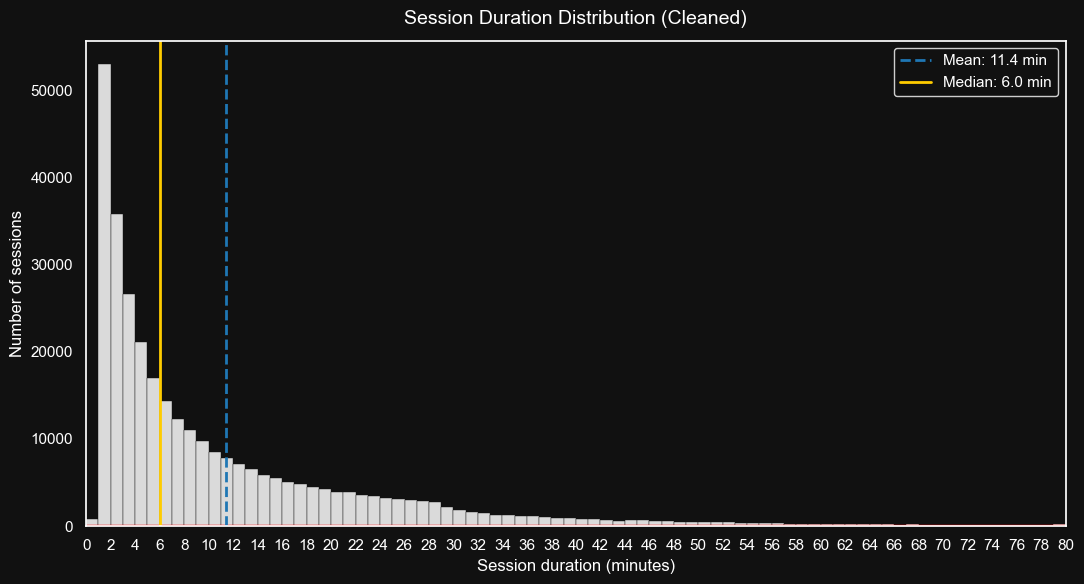

In [5]:
# Compute session duration in minutes
visits['session_duration_min'] = (
    (visits['End Ts'] - visits['Start Ts']).dt.total_seconds() / 60
)

# Inspect distribution
print(visits['session_duration_min'].describe(), "\n")

# Identify negative session durations
if (visits['session_duration_min'] < 0).any():
    print("Negative session durations found:")
    print(visits[visits['session_duration_min'] < 0], "\n")
else:
    print("No negative session durations found\n")

# Remove invalid negative durations
visits = visits[visits['session_duration_min'] > 0]

# Cap session duration at 2 hours (120 minutes) to remove extreme outliers
visits = visits[visits['session_duration_min'] <= 120]

# Updated distribution after cleaning
visits['session_duration_min'].describe()

# Visualize session duration distribution
# --- Local dark style ---
sns.set_theme(style="dark")

col = "session_duration_min"
data = visits[col].dropna()

mean_v = data.mean()
median_v = data.median()

fig, ax = plt.subplots(figsize=(11, 6))

# Backgrounds
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Histogram (bars)
sns.histplot(
    data=data,
    bins=80,
    binrange=(0, 80),
    stat="count",
    color="white",
    edgecolor="#111111",
    linewidth=0.3,
    alpha=0.85,
    ax=ax
)

# KDE (separate, full control)
sns.kdeplot(
    data=data,
    color="red",
    linewidth=2,
    ax=ax
)

# Mean & Median
ax.axvline(mean_v, color="#1f77b4", linestyle="--", linewidth=2,
           label=f"Mean: {mean_v:.1f} min")

ax.axvline(median_v, color="#ffcc00", linestyle="-", linewidth=2,
           label=f"Median: {median_v:.1f} min")

# Titles & labels
ax.set_title("Session Duration Distribution (Cleaned)",
             fontsize=14, color="white", pad=12)

ax.set_xlabel("Session duration (minutes)", fontsize=12, color="white")
ax.set_ylabel("Number of sessions", fontsize=12, color="white")

# Axis styling
ax.set_xlim(0, 80)
ax.set_xticks(np.arange(0, 81, 2))
ax.tick_params(colors="white")

for spine in ax.spines.values():
    spine.set_color("white")

# Legend
legend = ax.legend(
    frameon=True,
    facecolor="#111111",
    edgecolor="white"
)
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

In [6]:
# ------------------------------------------------------------
# Inspect orders dataset structure and basic statistics
# ------------------------------------------------------------
orders.info()
print()

display(orders.head())

print("\nRevenue distribution summary:")
display(orders['Revenue'].describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Buy Ts   50415 non-null  object 
 1   Revenue  50415 non-null  float64
 2   Uid      50415 non-null  uint64 
dtypes: float64(1), object(1), uint64(1)
memory usage: 1.2+ MB



,Buy Ts,Revenue,Uid
0,2017-06-01 00:10:00,17.00,10329302124590727494
1,2017-06-01 00:25:00,0.55,11627257723692907447
2,2017-06-01 00:27:00,0.37,17903680561304213844
3,2017-06-01 00:29:00,0.55,16109239769442553005
4,2017-06-01 07:58:00,0.37,14200605875248379450



Revenue distribution summary:


count    50415.000000
mean         4.999647
std         21.818359
min          0.000000
25%          1.220000
50%          2.500000
75%          4.890000
max       2633.280000
Name: Revenue, dtype: float64

In [7]:
# ------------------------------------------------------------
# Convert timestamps, validate data quality, and inspect revenue
# ------------------------------------------------------------

# Convert purchase timestamp to datetime
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'])
orders.info()

# Check for duplicates
print(f"\nDuplicate rows: {orders.duplicated().sum()}")

# Check for missing values
print("\nMissing values per column:")
print(orders.isna().sum())

# Inspect potential revenue outliers
print("\nOrders with unusually high revenue:")
display(orders[orders['Revenue'] > 500])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50415 entries, 0 to 50414
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Buy Ts   50415 non-null  datetime64[ns]
 1   Revenue  50415 non-null  float64       
 2   Uid      50415 non-null  uint64        
dtypes: datetime64[ns](1), float64(1), uint64(1)
memory usage: 1.2 MB

Duplicate rows: 0

Missing values per column:
Buy Ts     0
Revenue    0
Uid        0
dtype: int64

Orders with unusually high revenue:


,Buy Ts,Revenue,Uid
9229,2017-09-26 22:45:00,550.00,16152080406371512880
23165,2017-12-10 13:04:00,1195.64,5539673724080479777
23244,2017-12-10 20:17:00,2633.28,5539673724080479777
24341,2017-12-15 21:22:00,604.39,5539673724080479777
24607,2017-12-17 18:06:00,1109.10,11149926373378902217
32473,2018-02-01 19:28:00,607.44,11149926373378902217
36522,2018-02-23 08:54:00,1236.28,11149926373378902217
36682,2018-02-24 09:25:00,1221.37,11149926373378902217
40020,2018-03-15 19:22:00,856.78,11149926373378902217
40386,2018-03-18 09:13:00,1073.11,11149926373378902217


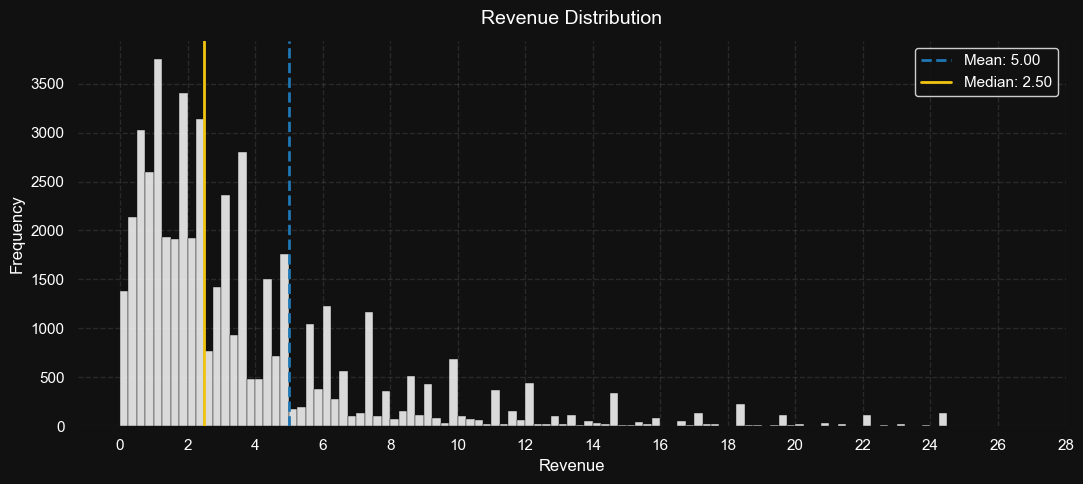

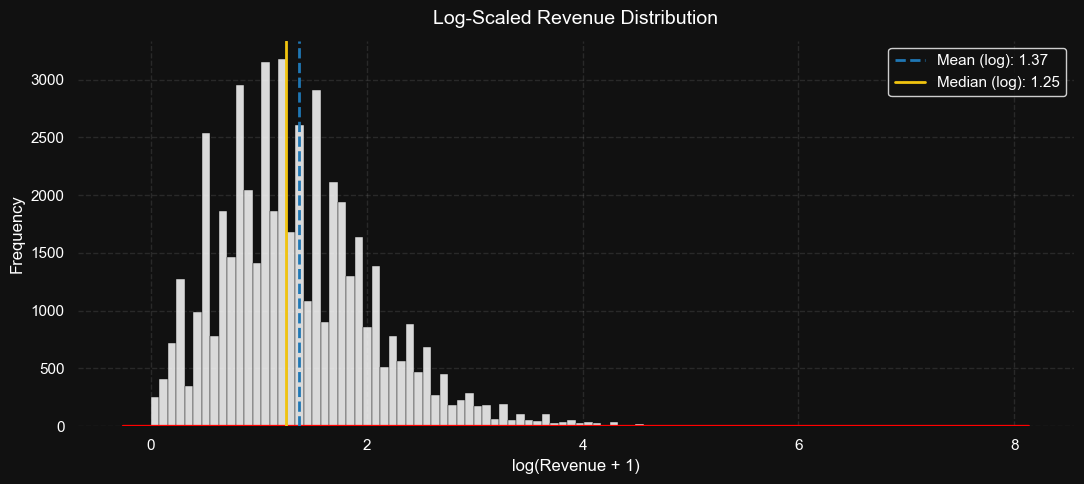

In [8]:
# ------------------------------------------------------------
# Revenue distribution (linear scale) — styled
# ------------------------------------------------------------
data = orders['Revenue']

mean_v = data.mean()
median_v = data.median()

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Histogram
sns.histplot(
    data=data,
    bins=100,
    binrange=(0, 25),
    color="white",
    edgecolor="#111111",
    linewidth=0.3,
    alpha=0.85,
    ax=ax
)

# Mean & Median
ax.axvline(mean_v, color="#1f77b4", linestyle="--", linewidth=2,
           label=f"Mean: {mean_v:.2f}")
ax.axvline(median_v, color="#f1c40f", linestyle="-", linewidth=2,
           label=f"Median: {median_v:.2f}")

# Styling
ax.set_title("Revenue Distribution", color="white", fontsize=14, pad=12)
ax.set_xlabel("Revenue", color="white")
ax.set_ylabel("Frequency", color="white")
ax.set_xticks(range(0, 30, 2))
ax.tick_params(colors="white")
ax.legend(facecolor="#111111", edgecolor="white", labelcolor="white")

# remove rectangle border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(True, linestyle="--", alpha=0.1)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Revenue distribution (log scale) — styled
# ------------------------------------------------------------
log_data = np.log1p(orders['Revenue'])

mean_log = log_data.mean()
median_log = log_data.median()

fig, ax = plt.subplots(figsize=(11, 5))
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#111111")

# Histogram
sns.histplot(
    data=log_data,
    bins=100,
    color="white",
    edgecolor="#111111",
    linewidth=0.3,
    alpha=0.85,
    ax=ax
)

# KDE (drawn separately for full control)
sns.kdeplot(
    data=log_data,
    color="red",
    linewidth=2,
    ax=ax
)

# Mean & Median
ax.axvline(mean_log, color="#1f77b4", linestyle="--", linewidth=2,
           label=f"Mean (log): {mean_log:.2f}")
ax.axvline(median_log, color="#f1c40f", linestyle="-", linewidth=2,
           label=f"Median (log): {median_log:.2f}")

# Styling
ax.set_title("Log-Scaled Revenue Distribution", color="white", fontsize=14, pad=12)
ax.set_xlabel("log(Revenue + 1)", color="white")
ax.set_ylabel("Frequency", color="white")
ax.tick_params(colors="white")
ax.legend(facecolor="#111111", edgecolor="white", labelcolor="white")

# remove rectangle border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.grid(True, linestyle="--", alpha=0.1)
plt.tight_layout()
plt.show()

#### Logarithmic scale for revenue

The raw revenue distribution is **highly right-skewed**, with most purchases concentrated at low values and a small number of high-revenue orders creating long tails. In this context, a standard linear scale makes it difficult to observe the structure of the data beyond the most frequent values.

Applying a logarithmic transformation (`log(Revenue + 1)`) allows:

- A clearer visualization of the **overall shape** of the revenue distribution.
- Better identification of **clusters and patterns** among typical purchases.
- Improved visibility of **outliers**, without allowing extreme values to dominate the scale.
- More reliable interpretation of central tendency (mean and median) in skewed data.

This transformation does **not change the underlying data**, but it provides a more informative view of user spending behavior, particularly important for downstream analyses: LTV, cohort comparison, and marketing efficiency evaluation.

It confirms a log-normal pattern with a long but consistent tail, indicating that high-value purchases are rare but structurally expected rather than anomalous.

In [9]:
# ------------------------------------------------------------
# Revenue outlier analysis using the IQR method
# ------------------------------------------------------------

# Compute quartiles and interquartile range
Q1 = orders['Revenue'].quantile(0.25)
Q3 = orders['Revenue'].quantile(0.75)
IQR = Q3 - Q1

# Define upper bound for high-end outliers
upper_bound = Q3 + 1.5 * IQR
print(f"Upper outlier threshold for Revenue: {upper_bound}")

# Identify outlier transactions
outliers = orders[orders['Revenue'] > upper_bound]

print(f"Number of outlier transactions: {len(outliers)}")
print(f"Outliers as percentage of total orders: {100 * len(outliers) / len(orders):.2f}%\n")

# Create an explicit outlier flag
orders['outlier'] = np.where(orders['Revenue'] > upper_bound, 'yes', 'no')

print("Outlier flag preview:")
display(orders.head())

print("\nOutlier counts:")
print(orders['outlier'].value_counts())

# Create a cleaned orders dataset excluding high-end outliers
orders_clean = orders[orders['outlier'] == 'no'][['Buy Ts', 'Revenue', 'Uid']]

# Summary statistics for cleaned dataset
orders_clean.describe()

Upper outlier threshold for Revenue: 10.395
Number of outlier transactions: 3990
Outliers as percentage of total orders: 7.91%

Outlier flag preview:


,Buy Ts,Revenue,Uid,outlier
0,2017-06-01 00:10:00,17.00,10329302124590727494,yes
1,2017-06-01 00:25:00,0.55,11627257723692907447,no
2,2017-06-01 00:27:00,0.37,17903680561304213844,no
3,2017-06-01 00:29:00,0.55,16109239769442553005,no
4,2017-06-01 07:58:00,0.37,14200605875248379450,no



Outlier counts:
outlier
no     46425
yes     3990
Name: count, dtype: int64


,Buy Ts,Revenue,Uid
count,46425,46425.000000,4.642500e+04
mean,2017-12-20 20:09:20.290791424,3.017129,9.106841e+18
min,2017-06-01 00:25:00,0.000000,3.135781e+14
25%,2017-10-14 13:21:00,1.220000,4.505629e+18
50%,2017-12-22 16:39:00,2.440000,9.109123e+18
75%,2018-03-02 20:08:00,4.280000,1.371089e+19
max,2018-06-01 00:02:00,10.390000,1.844617e+19
std,NaN,2.338915,5.298538e+18


In [10]:
# Inspect orders with zero revenue
display(orders_clean[orders_clean['Revenue'] == 0].head(10))

print(
    f"Number of orders with zero revenue: "
    f"{orders_clean[orders_clean['Revenue'] == 0]['Revenue'].count()}"
)

,Buy Ts,Revenue,Uid
1802,2017-06-22 18:19:00,0.0,17030528792926543083
2787,2017-07-07 15:54:00,0.0,10281425020415612933
4783,2017-08-02 14:54:00,0.0,184148767273119549
5095,2017-08-09 14:48:00,0.0,5603453646174104178
5863,2017-08-23 13:43:00,0.0,5603453646174104178
6393,2017-08-30 16:30:00,0.0,5603453646174104178
6995,2017-09-06 13:57:00,0.0,5603453646174104178
7104,2017-09-07 14:37:00,0.0,5603453646174104178
7488,2017-09-11 16:53:00,0.0,10169885790465067808
8160,2017-09-18 16:49:00,0.0,2883839899480223178


Number of orders with zero revenue: 51


In [11]:
# Remove orders with zero revenue
orders_clean = orders_clean[orders_clean['Revenue'] > 0]

orders_clean.describe()

,Buy Ts,Revenue,Uid
count,46374,46374.000000,4.637400e+04
mean,2017-12-20 20:23:46.183206144,3.020447,9.110212e+18
min,2017-06-01 00:25:00,0.010000,3.135781e+14
25%,2017-10-14 13:14:00,1.220000,4.508506e+18
50%,2017-12-22 17:28:30,2.440000,9.114903e+18
75%,2018-03-02 20:27:45,4.280000,1.371641e+19
max,2018-06-01 00:02:00,10.390000,1.844617e+19
std,NaN,2.338059,5.298619e+18


In [12]:
# Number of purchases per user
print(orders_clean.groupby('Uid')['Revenue'].count().value_counts().head(10))
print()

# Top 10 users with the highest number of purchases
orders_clean.groupby('Uid')['Revenue'].count().sort_values(ascending=False).head(10)

Revenue
1     28799
2      4040
3       972
4       325
5       131
6        64
7        29
8        23
9        15
10       14
Name: count, dtype: int64



Uid
13888745432979765063    212
3644482766749211722     211
11920452646463905188    201
6731421022966725351     142
3501596628378158474     140
5139615590553126732     136
10343016064897450067    119
10116135452198588850    112
6166747268563050393     111
6948781160947906362     106
Name: Revenue, dtype: int64

In [13]:
# Review basic dataset structure and summary statistics
costs.info()
print()

# Descriptive statistics for marketing costs
display(costs[['costs']].describe())

# Preview first rows
costs.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   source_id  2542 non-null   int64  
 1   dt         2542 non-null   object 
 2   costs      2542 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 59.7+ KB



,costs
count,2542.000000
mean,129.477427
std,156.296628
min,0.540000
25%,21.945000
50%,77.295000
75%,170.065000
max,1788.280000


,source_id,dt,costs
0,1,2017-06-01,75.20
1,1,2017-06-02,62.25
2,1,2017-06-03,36.53
3,1,2017-06-04,55.00
4,1,2017-06-05,57.08


In [14]:
# Convert date column to datetime format
costs['dt'] = pd.to_datetime(costs['dt'])

# Verify updated data types
costs.info()

# Check for duplicated rows
print(f"\nDuplicated rows:\n{costs.duplicated().sum()}")

# Check for missing values
print(f"\nMissing values:\n{costs.isna().sum()}")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB

Duplicated rows:
0

Missing values:
source_id    0
dt           0
costs        0
dtype: int64


In [15]:
# Calculate total marketing costs
total_costs = costs['costs'].sum()
print(f"Total marketing costs: {total_costs}")

# Marketing costs by acquisition source
costs_per_source = (
    costs
    .groupby('source_id')['costs']
    .sum()
    .sort_values(ascending=False)
)

print("\nMarketing costs by source:")
print(costs_per_source)

Total marketing costs: 329131.62

Marketing costs by source:
source_id
3     141321.63
4      61073.60
5      51757.10
2      42806.04
1      20833.27
10      5822.49
9       5517.49
Name: costs, dtype: float64


### Conclusions — Data Optimization & Preprocessing

During this stage, the three core datasets (`visits`, `orders`, and `costs`) were thoroughly reviewed, cleaned, and prepared to ensure analytical reliability before proceeding to cohort and profitability analysis.

Key findings and actions taken:

- All timestamp columns were successfully converted to proper `datetime` formats, enabling accurate temporal analysis and cohort construction.
- Session duration was derived from visit start and end times. Negative and unrealistically long sessions (greater than 120 minutes) were identified and removed, as they likely represent logging errors or abnormal behavior.
- The distribution of session duration is highly right-skewed, with most user sessions concentrated in short time windows and a small number of extreme values.
- Order revenue data exhibited a strong right-skew with a long tail of high-value purchases. Logarithmic scaling was used during exploration to better understand distribution shape without altering monetary values.
- Revenue outliers were identified using the IQR method. These high-value transactions represent a very small proportion of total orders and were retained for exploratory purposes, but flagged to avoid distortion in aggregate metrics.
- Orders with zero revenue were removed, as they do not contribute to monetization analysis and may represent test or invalid transactions.
- Marketing cost data showed no missing or duplicate values, and costs were successfully aggregated by acquisition source, providing a clean basis for CAC and ROMI calculations.

Overall, this preprocessing step ensured:
- Consistent temporal alignment across datasets,
- Removal of invalid or misleading records,
- Preservation of economically meaningful behavior,
- A reliable foundation for cohort analysis, customer lifetime value estimation, and marketing efficiency evaluation.

With the data validated and optimized, the analysis can confidently proceed to user behavior, cohort dynamics, and profitability assessment.

## EDA — Exploratory Data Analysis (User Behavior)

The purpose of this stage is to understand **how users interact with the product over time**, independently of revenue or marketing costs.

Before evaluating monetization and marketing efficiency, it is critical to analyze baseline user behavior to establish context around engagement, usage patterns, and retention tendencies.

This section focuses on answering the following questions:

### Key Questions
- How many users interact with the product on a daily, weekly, and monthly basis (DAU / WAU / MAU)?
- How many sessions are generated per day?
- What is the typical duration of a user session?
- How frequently do users return to the platform?

Understanding these behavioral patterns provides the foundation for interpreting downstream revenue metrics and cohort-based performance in later stages

In [16]:
# ------------------------------------------------------------
# Active users over time: Daily, Weekly, Monthly
# ------------------------------------------------------------

# Create date-based features
visits["date"] = visits["Start Ts"].dt.date
visits["week"] = visits["Start Ts"].dt.to_period("W").apply(lambda x: x.start_time)
visits["month"] = visits["Start Ts"].dt.to_period("M").astype(str)

# Daily Active Users (DAU)
daily_users = visits.groupby("date")["Uid"].nunique()

# Weekly Active Users (WAU)
weekly_users = visits.groupby("week")["Uid"].nunique()

# Monthly Active Users (MAU)
monthly_users = visits.groupby("month")["Uid"].nunique()

# Quick sanity check
print("Daily Active Users (sample):")
display(daily_users.head())

print("\nWeekly Active Users (sample):")
display(weekly_users.head())

print("\nMonthly Active Users:")
display(monthly_users)

Daily Active Users (sample):


date
2017-06-01    545
2017-06-02    549
2017-06-03    400
2017-06-04    416
2017-06-05    736
Name: Uid, dtype: int64


Weekly Active Users (sample):


week
2017-05-29    1814
2017-06-05    3697
2017-06-12    2514
2017-06-19    2564
2017-06-26    2727
Name: Uid, dtype: int64


Monthly Active Users:


month
2017-06    11880
2017-07    12718
2017-08    10464
2017-09    17113
2017-10    26786
2017-11    29721
2017-12    28577
2018-01    25921
2018-02    25947
2018-03    24858
2018-04    18817
2018-05    18560
Name: Uid, dtype: int64

In [17]:
# ------------------------------------------------------------
# Number of sessions per day
# (A user may generate multiple sessions)
# ------------------------------------------------------------

# Each row in `visits` represents one session
daily_sessions = visits.groupby('date').size()

display(daily_sessions.head())

date
2017-06-01    597
2017-06-02    593
2017-06-03    428
2017-06-04    447
2017-06-05    804
dtype: int64

In [18]:
# ------------------------------------------------------------
# Session duration analysis
# ------------------------------------------------------------

# Session duration in seconds
visits['session_duration_sec'] = (
    visits['End Ts'] - visits['Start Ts']
).dt.total_seconds()

# Session duration in minutes
visits['session_duration_min'] = visits['session_duration_sec'] / 60

display(visits[['Uid', 'Start Ts', 'End Ts', 'session_duration_min']].head())

,Uid,Start Ts,End Ts,session_duration_min
0,16879256277535980062,2017-12-20 17:20:00,2017-12-20 17:38:00,18.0
1,104060357244891740,2018-02-19 16:53:00,2018-02-19 17:21:00,28.0
3,16174680259334210214,2018-05-20 10:59:00,2018-05-20 11:23:00,24.0
5,16007536194108375387,2017-09-03 21:35:00,2017-09-03 21:36:00,1.0
6,6661610529277171451,2018-01-30 11:13:00,2018-01-30 12:09:00,56.0


In [19]:
# ------------------------------------------------------------
# User return frequency
# ------------------------------------------------------------

# Calculate each user's first activity date
first_activity_date = (
    visits
    .groupby('Uid')['date']
    .min()
    .rename('first_activity_date')
)

# Attach first activity date back to visits table
visits = visits.join(first_activity_date, on='Uid')

display(visits[['Uid', 'date', 'first_activity_date']].head())

,Uid,date,first_activity_date
0,16879256277535980062,2017-12-20,2017-12-20
1,104060357244891740,2018-02-19,2018-02-19
3,16174680259334210214,2018-05-20,2018-03-09
5,16007536194108375387,2017-09-03,2017-09-03
6,6661610529277171451,2018-01-30,2017-06-29


In [20]:
# ------------------------------------------------------------
# Weekly cohort construction
# ------------------------------------------------------------

# Create the user's first activity week (cohort start)
visits['first_activity_week'] = (
    pd.to_datetime(visits['first_activity_date'])
    .dt.to_period('W')
    .apply(lambda x: x.start_time)
)

# Calculate weekly cohort lifetime
# (number of weeks since the user's first activity)
visits['cohort_lifetime_weekly'] = (
    (visits['week'] - visits['first_activity_week']) 
    / np.timedelta64(1, 'W')
).astype(int)

display(visits[['Uid', 'week', 'first_activity_week', 'cohort_lifetime_weekly']].head(3))

,Uid,week,first_activity_week,cohort_lifetime_weekly
0,16879256277535980062,2017-12-18,2017-12-18,0
1,104060357244891740,2018-02-19,2018-02-19,0
3,16174680259334210214,2018-05-14,2018-03-05,10


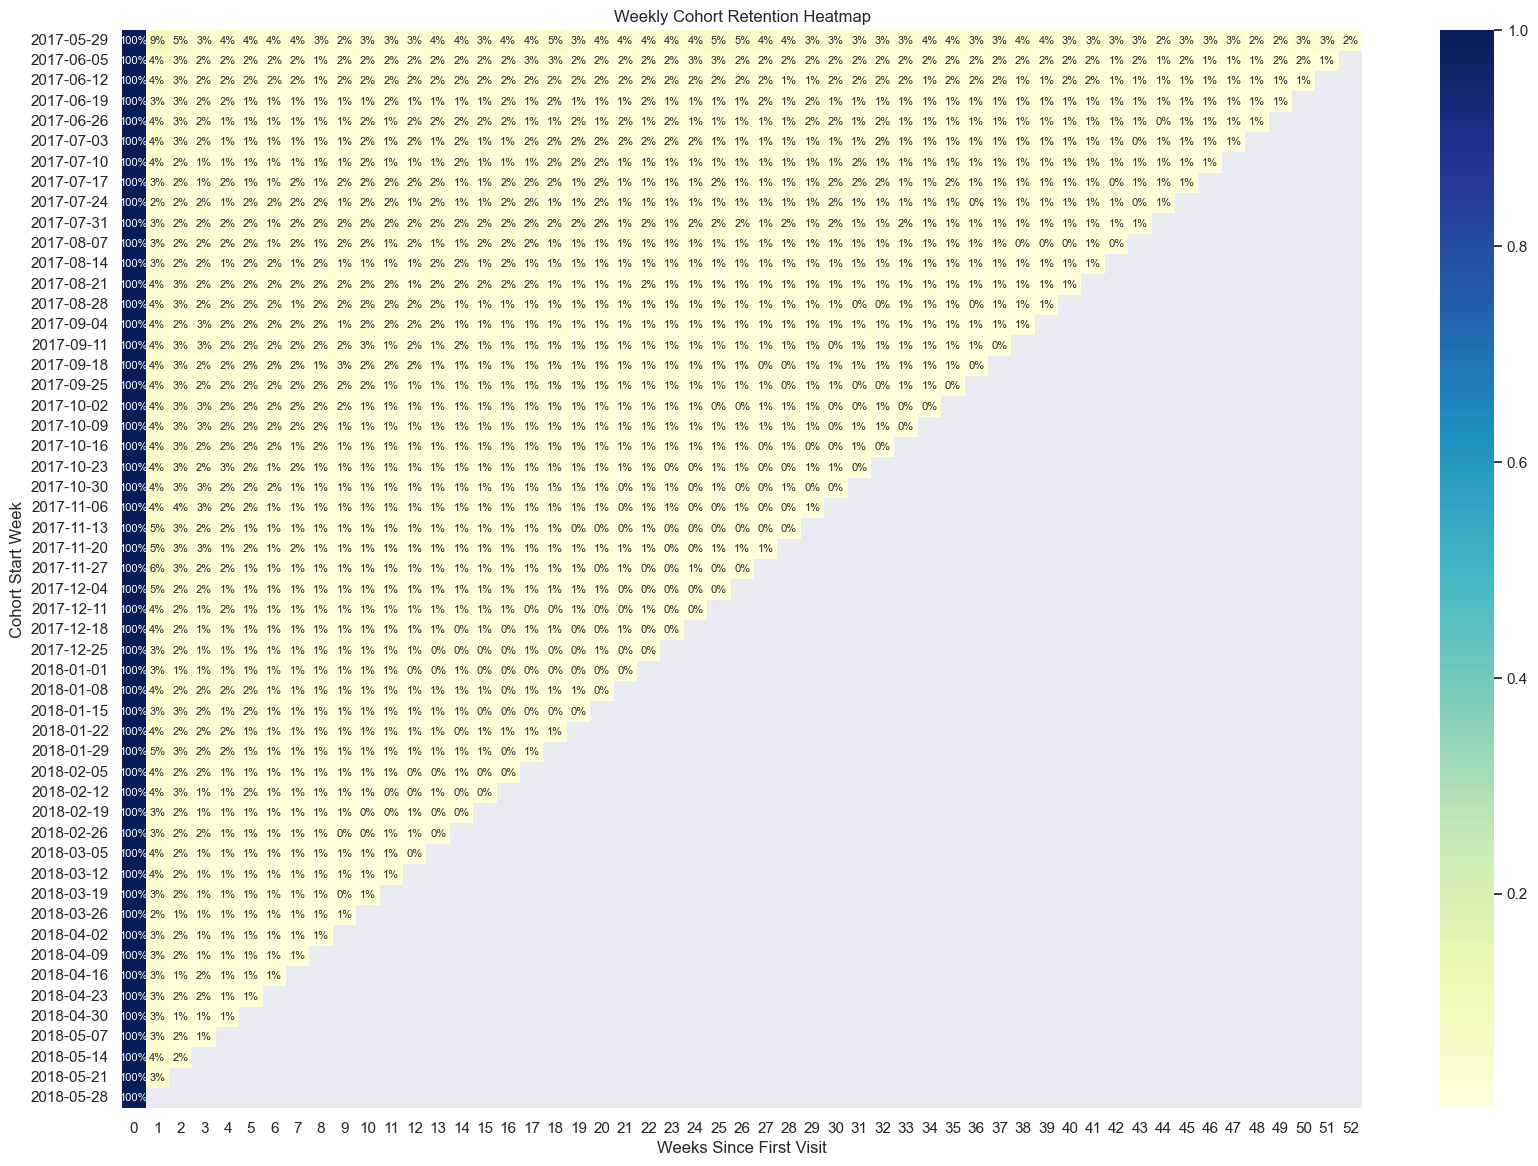

In [21]:
# ------------------------------------------------------------
# Weekly cohort aggregation & retention calculation
# ------------------------------------------------------------

# Aggregate unique users by cohort start week and cohort lifetime
cohorts = (
    visits
    .groupby(['first_activity_week', 'cohort_lifetime_weekly'])['Uid']
    .nunique()
    .reset_index(name='active_users')
)

# Extract cohort size (users at lifetime = 0)
initial_users = (
    cohorts[cohorts['cohort_lifetime_weekly'] == 0]
    [['first_activity_week', 'active_users']]
    .rename(columns={'active_users': 'cohort_size'})
)

# Merge cohort size back into cohort table
cohorts = cohorts.merge(initial_users, on='first_activity_week')

# Compute retention rate
cohorts['retention_rate'] = cohorts['active_users'] / cohorts['cohort_size']

# ------------------------------------------------------------
# Build retention pivot table
# ------------------------------------------------------------

retention_pivot = cohorts.pivot_table(
    index='first_activity_week',
    columns='cohort_lifetime_weekly',
    values='retention_rate',
    aggfunc='mean'
)

# Format index for readability
retention_pivot.index = retention_pivot.index.strftime('%Y-%m-%d')

# ------------------------------------------------------------
# Retention heatmap (weekly cohorts)
# ------------------------------------------------------------

plt.figure(figsize=(20, 14))
sns.heatmap(
    retention_pivot,
    annot=True,
    fmt=".0%",
    annot_kws={"size": 8},
    cmap="YlGnBu"
)

plt.title('Weekly Cohort Retention Heatmap')
plt.xlabel('Weeks Since First Visit')
plt.ylabel('Cohort Start Week')
plt.yticks(rotation=0)
plt.show()

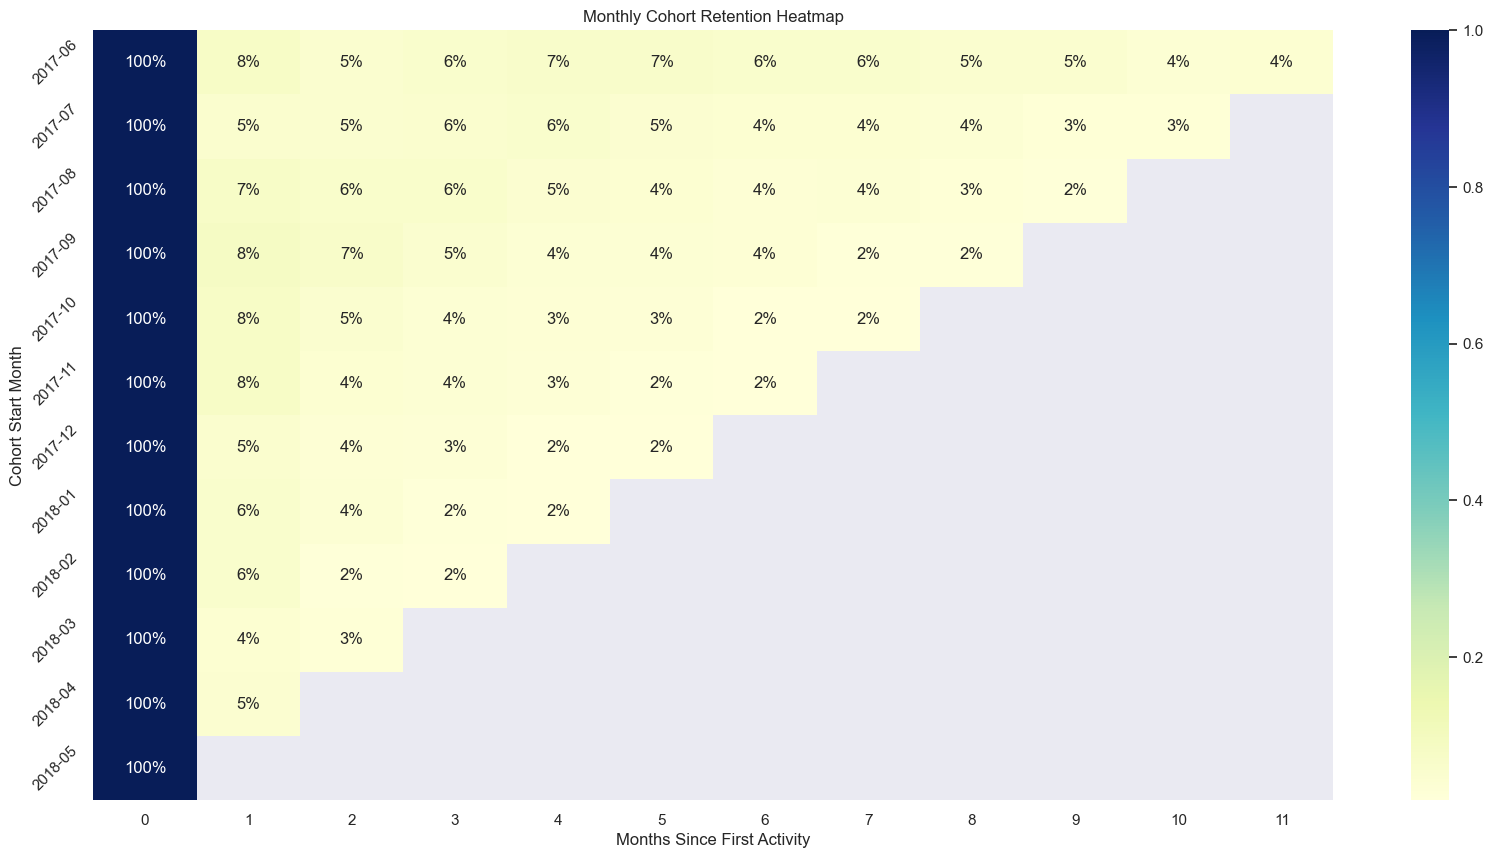

In [22]:
# ------------------------------------------------------------
# Monthly cohort retention (month-based cohorts)
# ------------------------------------------------------------

# Cohort start month (first activity month)
visits['first_activity_month'] = (
    pd.to_datetime(visits['first_activity_date'])
    .dt.to_period('M')
    .astype(str)
)

# Active users by cohort month and activity month
monthly_cohorts = (
    visits
    .groupby(['first_activity_month', 'month'])['Uid']
    .nunique()
    .reset_index(name='active_users')
)

# Convert YYYY-MM strings to datetime for month-diff calculation
monthly_cohorts['first_activity_month_dt'] = pd.to_datetime(
    monthly_cohorts['first_activity_month'], format='%Y-%m'
)
monthly_cohorts['month_dt'] = pd.to_datetime(monthly_cohorts['month'], format='%Y-%m')

# Cohort lifetime in months (0, 1, 2, ...)
monthly_cohorts['cohort_lifetime_months'] = (
    (monthly_cohorts['month_dt'].dt.to_period('M') - monthly_cohorts['first_activity_month_dt'].dt.to_period('M'))
    .apply(lambda x: x.n)
    .astype(int)
)

# Cohort size (users at lifetime = 0)
initial_users = (
    monthly_cohorts[monthly_cohorts['cohort_lifetime_months'] == 0]
    [['first_activity_month', 'active_users']]
    .rename(columns={'active_users': 'cohort_size'})
)

# Merge cohort size + compute retention
monthly_cohorts = monthly_cohorts.merge(initial_users, on='first_activity_month')
monthly_cohorts['retention_rate'] = monthly_cohorts['active_users'] / monthly_cohorts['cohort_size']

# Pivot table for heatmap
monthly_retention_pivot = monthly_cohorts.pivot_table(
    index='first_activity_month',
    columns='cohort_lifetime_months',
    values='retention_rate',
    aggfunc='mean'
)

# ------------------------------------------------------------
# Monthly retention heatmap
# ------------------------------------------------------------

plt.figure(figsize=(20, 10))
sns.heatmap(monthly_retention_pivot, annot=True, fmt='.0%', cmap='YlGnBu')

plt.title('Monthly Cohort Retention Heatmap')
plt.xlabel('Months Since First Activity')
plt.ylabel('Cohort Start Month')
plt.yticks(rotation=45)
plt.show()

### Conclusions — EDA — User Retention & Cohort Analysis

The cohort analysis reveals a **sharp decline in user retention immediately after the first interaction**, observable at both the weekly and monthly levels.

### Key observations

- **Early churn is very high**:  
  Weekly cohorts show that retention drops significantly after the **first week of activity**. Even for the best-performing cohort (users whose first activity started during the week of **2017-05-29**), **less than 10% of users return after week one**.

- **Monthly retention remains low**:  
  At the monthly level, retention typically falls to **4–8% by the first month** after initial activity, indicating that the majority of users do not return shortly after their first interaction.

- **Stabilization after the first month**:  
  From approximately the **fourth week (around one month)** onward, retention stabilizes between **2% and 4%** across most cohorts. This suggests the presence of a **small but consistent core of loyal users** who continue engaging with the service over time.

- **Notable cohort anomaly (June 2017)**:  
  The cohort that began in **June 2017** exhibits relatively higher retention rates compared to later cohorts. This deviation may indicate:
  - Stronger or more effective early marketing campaigns,
  - A shift in acquisition strategy that initially attracted higher-quality users,
  - Or increased novelty or product-market fit during the early launch phase.

- **Long-term trend**:  
  Across cohorts, there is a **gradual downward trend in retention over time**, suggesting diminishing effectiveness of user acquisition or engagement strategies as the product matures.

### Implications

Overall, the analysis indicates that while the platform is capable of retaining a small segment of loyal users, **most users disengage very quickly**. Improving early user experience, onboarding, and post-acquisition engagement appears critical. Additionally, investigating the conditions surrounding higher-retention cohorts (such as June 2017) could provide actionable insights for optimizing future marketing and retention strategies.

These findings provide a solid foundation for the next stages of analysis, including revenue dynamics, lifetime value, and the relationship between acquisition cost and long-term user behavior.

## EDA — Revenue & Customer Value Analysis

This section focuses on understanding **how and when users generate revenue**, moving from behavioral analysis to monetization dynamics.

Key questions addressed:

- **Time to First Purchase:**  
  How long does it take for users to convert after their first interaction?  
  Conversion timing is analyzed using cohort-based approaches (e.g., same-day vs. delayed conversion).

- **Purchase Frequency:**  
  How many orders do users place over time, and how is purchasing behavior distributed across users?

- **Average Order Value (AOV):**  
  What is the typical purchase size, and how skewed is the revenue distribution?

- **Customer Lifetime Value (LTV):**  
  How much total revenue does an average customer generate over their lifecycle?

In [23]:
# ------------------------------------------------------------
# Time to First Purchase — User-level conversion timing
# ------------------------------------------------------------

# Identify first purchase timestamp per user
orders['first_purchase_ts'] = orders.groupby('Uid')['Buy Ts'].transform('min')

# Extract first activity date per user from visits
user_first_activity = (
    visits[['Uid', 'first_activity_date']]
    .drop_duplicates()
)

# Merge first activity information into orders
orders = orders.merge(
    user_first_activity,
    on='Uid',
    how='left'
)

# Preview result
orders[['Uid', 'first_activity_date', 'first_purchase_ts']].head()

,Uid,first_activity_date,first_purchase_ts
0,10329302124590727494,2017-06-01,2017-06-01 00:10:00
1,11627257723692907447,2017-06-01,2017-06-01 00:25:00
2,17903680561304213844,2017-06-01,2017-06-01 00:27:00
3,16109239769442553005,2017-06-01,2017-06-01 00:29:00
4,14200605875248379450,2017-06-01,2017-06-01 07:58:00


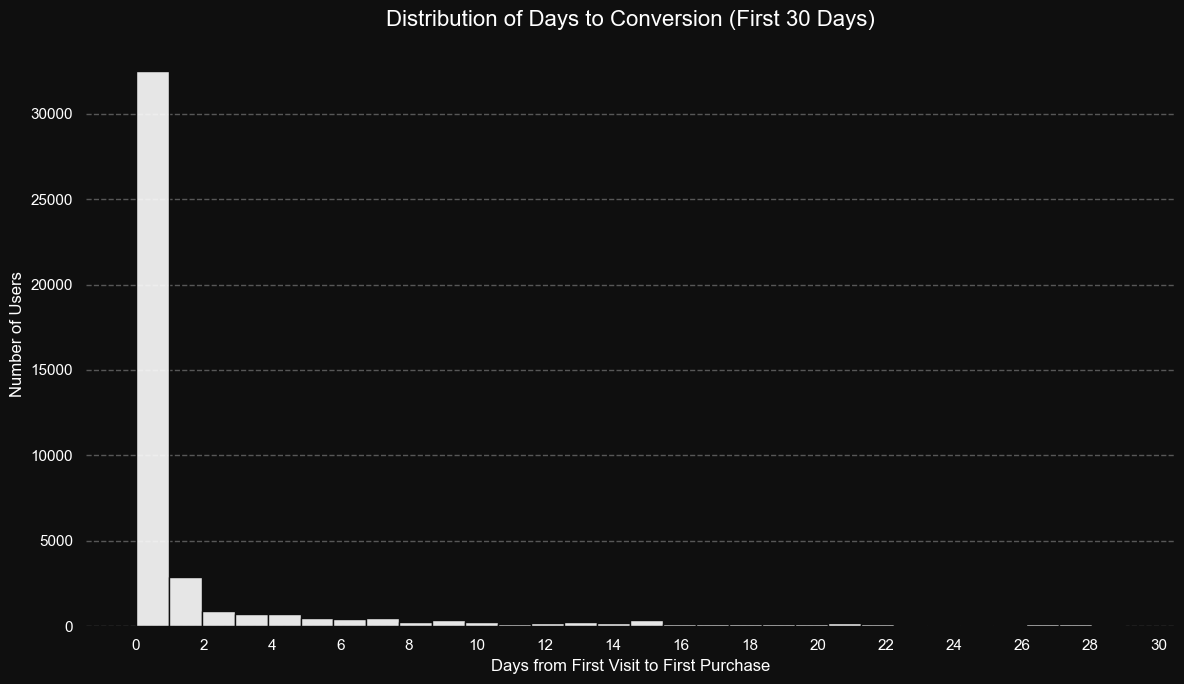

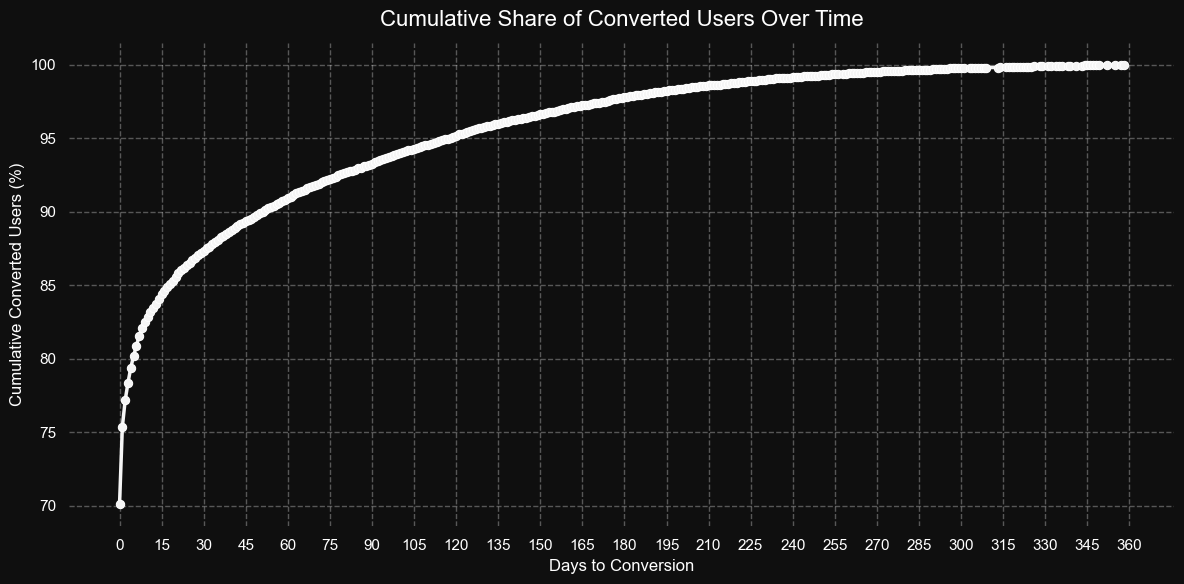

,conversion_time_days,users,cum_users,cum_pct
0,0,25150,25150,70.096714
1,1,1887,27037,75.356058
2,2,644,27681,77.150980
3,3,430,28111,78.349452
4,4,367,28478,79.372335


In [24]:
# ------------------------------------------------------------
# Conversion lag (days): first activity -> first purchase
# ------------------------------------------------------------

# --- Ensure datetime types ---
orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'], errors='coerce')

# visits already has first_activity_date from your earlier section, but ensure it exists
if 'first_activity_date' not in visits.columns:
    visits['date'] = visits['Start Ts'].dt.date
    first_activity_date = visits.groupby('Uid')['date'].min()
    visits = visits.join(first_activity_date.rename('first_activity_date'), on='Uid')

# --- Ensure first_purchase exists ---
if 'first_purchase' not in orders.columns:
    orders['first_purchase'] = orders.groupby('Uid')['Buy Ts'].transform('min')

# --- Ensure first_activity_date is merged into orders ---
if 'first_activity_date' not in orders.columns:
    user_first_activity = visits[['Uid', 'first_activity_date']].drop_duplicates('Uid')
    orders = orders.merge(user_first_activity, on='Uid', how='left')

# --- Build conversion_time_days ---
orders['conversion_time_days'] = (
    orders['first_purchase'] - pd.to_datetime(orders['first_activity_date'])
).dt.days.astype('Int64')

# Keep valid values only (and don't destroy original orders permanently)
orders_conv = orders[
    orders['conversion_time_days'].notna() &
    (orders['conversion_time_days'] >= 0)
].copy()

# Aggregate unique users by conversion lag
conversion_counts = (
    orders_conv.groupby('conversion_time_days')['Uid']
    .nunique()
    .reset_index(name='users')
    .sort_values('conversion_time_days')
)

# =========================
# Plot 1 — Conversion lag distribution (first 30 days)
# =========================
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#0f0f0f")

sns.histplot(
    data=orders_conv.loc[orders_conv['conversion_time_days'] < 30],
    x='conversion_time_days',
    bins=30,
    stat="count",
    color="white",
    edgecolor="#0f0f0f",
    alpha=0.9,
    ax=ax
)

ax.set_title("Distribution of Days to Conversion (First 30 Days)", fontsize=16, color="white", pad=12)
ax.set_xlabel("Days from First Visit to First Purchase", color="white")
ax.set_ylabel("Number of Users", color="white")
ax.tick_params(colors="white")
ax.grid(axis="y", linestyle="--", alpha=0.3)

# remove rectangle border
for spine in ax.spines.values():
    spine.set_visible(False)
plt.xticks(range(0, 32, 2))
plt.tight_layout()
plt.show()

# =========================
# Plot 2 — Cumulative conversion curve (CDF)
# =========================
conversion_cdf = conversion_counts.copy()
conversion_cdf['cum_users'] = conversion_cdf['users'].cumsum()

total_users = orders_conv['Uid'].nunique()
conversion_cdf['cum_pct'] = 100 * conversion_cdf['cum_users'] / total_users

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#0f0f0f")
ax.set_facecolor("#0f0f0f")

sns.lineplot(
    data=conversion_cdf[conversion_cdf['cum_pct'] < 100],
    x='conversion_time_days',
    y='cum_pct',
    marker='o',
    linewidth=2.5,
    color="whitesmoke",
    ax=ax
)

ax.set_title("Cumulative Share of Converted Users Over Time", fontsize=16, color="white", pad=12)
ax.set_xlabel("Days to Conversion", color="white")
ax.set_ylabel("Cumulative Converted Users (%)", color="white")
ax.tick_params(colors="white")
ax.grid(True, linestyle="--", alpha=0.3)

# remove rectangle border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.xticks(range(0, 365, 15))
plt.tight_layout()
plt.show()

conversion_cdf.head()

In [25]:
# ------------------------------------------------------------
# First-touch Source Id (from earliest visit) + conversions by source
# ------------------------------------------------------------

# Ensure visits are ordered so "first" truly means first visit
visits_sorted = visits.sort_values(['Uid', 'Start Ts'])

# First Source Id per user (first-touch)
first_source = visits_sorted.groupby('Uid')['Source Id'].first().rename('first_source')

# Merge into orders (no duplicate rows)
orders = orders.merge(first_source, on='Uid', how='left')

# Make sure we have conversion_time_days available
if 'conversion_time_days' not in orders.columns:
    orders['Buy Ts'] = pd.to_datetime(orders['Buy Ts'], errors='coerce')
    if 'first_purchase' not in orders.columns:
        orders['first_purchase'] = orders.groupby('Uid')['Buy Ts'].transform('min')

    if 'first_activity_date' not in orders.columns:
        user_first_activity = visits_sorted[['Uid', 'first_activity_date']].drop_duplicates('Uid')
        orders = orders.merge(user_first_activity, on='Uid', how='left')

    orders['conversion_time_days'] = (
        orders['first_purchase'] - pd.to_datetime(orders['first_activity_date'])
    ).dt.days.astype('Int64')

# Filter valid conversion lags
orders_conv = orders[
    orders['conversion_time_days'].notna() &
    (orders['conversion_time_days'] >= 0)
].copy()

# Users converted by source and conversion lag
conversion_by_source = (
    orders_conv
    .groupby(['first_source', 'conversion_time_days'])['Uid']
    .nunique()
    .reset_index(name='users')
)

conversion_by_source.head()

,first_source,conversion_time_days,users
0,1.0,0,2229
1,1.0,1,159
2,1.0,2,54
3,1.0,3,46
4,1.0,4,21


In [26]:
# ------------------------------------------------------------
# Fast conversion rate (<= 7 days) by acquisition source
# Robust: does NOT assume conversion_by_source has 'Uid'
# ------------------------------------------------------------

# 1) Ensure we have a conversion-days column in orders (typo-safe)
if "conversion_time_days" in orders.columns:
    day_col_orders = "conversion_time_days"
elif "convertion_time_days" in orders.columns:
    day_col_orders = "convertion_time_days"
else:
    raise KeyError("orders must contain 'conversion_time_days' or 'convertion_time_days'")

# 2) Build a clean user-level table: one row per user, with first_source + conversion days
#    (This avoids double-counting users with multiple orders)
user_conv = (
    orders.dropna(subset=["Uid", "first_source", day_col_orders])
    .sort_values(["Uid", day_col_orders])
    .drop_duplicates("Uid")[["Uid", "first_source", day_col_orders]]
    .rename(columns={day_col_orders: "conversion_time_days"})
)

# 3) Fast conversions (<= 7 days) per source (unique users)
fast_conv = (
    user_conv[user_conv["conversion_time_days"] <= 7]
    .groupby("first_source")["Uid"]
    .nunique()
)

# 4) Total users per source (unique users)
total_users_source = user_conv.groupby("first_source")["Uid"].nunique()

# 5) Rate
fast_conversion_rate = (
    (fast_conv / total_users_source)
    .fillna(0)
    .sort_values(ascending=False)
    .rename("Fast Conversion Rate")
    .reset_index()
)

display(fast_conversion_rate.head(10))

,first_source,Fast Conversion Rate
0,7.0,1.000000
1,1.0,0.870458
2,10.0,0.866208
3,5.0,0.849277
4,4.0,0.816102
5,3.0,0.811540
6,2.0,0.779073
7,9.0,0.559557


/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/1806893462.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


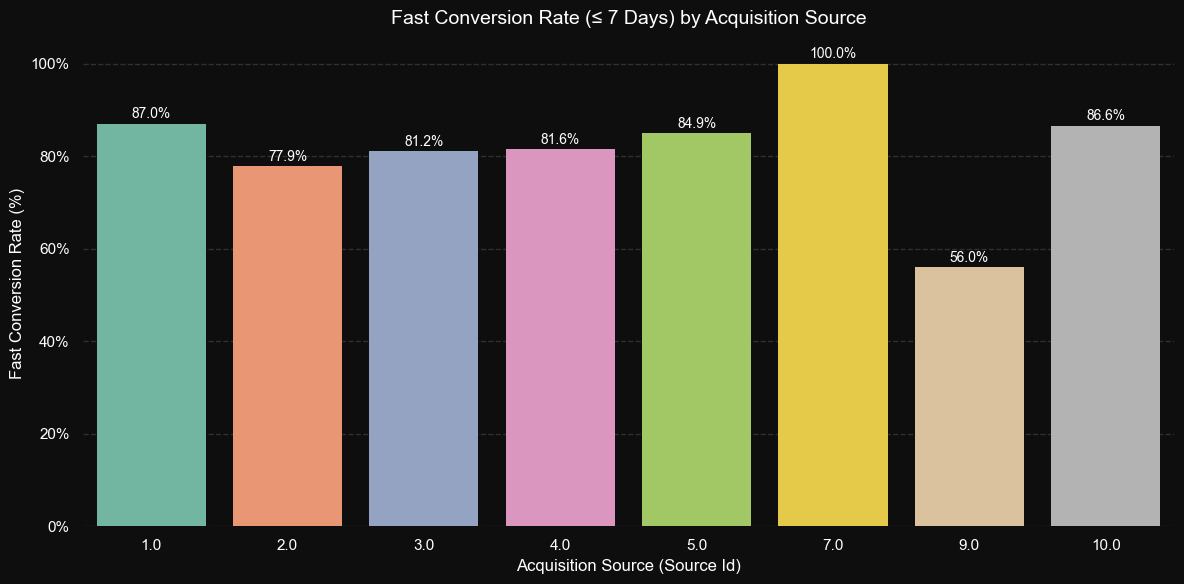

In [27]:
# ------------------------------------------------------------
# Fast conversion rate (≤ 7 days) by acquisition source
# ------------------------------------------------------------

palette = sns.color_palette("Set2", n_colors=len(fast_conversion_rate))

plt.figure(figsize=(12, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=fast_conversion_rate,
    x="first_source",
    y="Fast Conversion Rate",
    palette=palette,
    ax=ax
)

# Titles & labels
ax.set_title(
    "Fast Conversion Rate (≤ 7 Days) by Acquisition Source",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Acquisition Source (Source Id)", fontsize=12, color="white")
ax.set_ylabel("Fast Conversion Rate (%)", fontsize=12, color="white")

# Axis formatting
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

# Grid
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Value labels
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + 0.005,
        f"{h*100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white"
    )

# remove bar border 
for patch in ax.patches:
    patch.set_edgecolor("none")

# remove rectangle border
for spine in ax.spines.values():
    spine.set_visible(False)
    
plt.tight_layout()
plt.show()

,Source Id,Total Conversion Rate
0,10.0,0.181591
1,1.0,0.165691
2,3.0,0.152092
3,2.0,0.145764
4,4.0,0.134559
5,5.0,0.134508
6,9.0,0.127457
7,7.0,0.030303
8,6.0,0.000000


/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/749755208.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


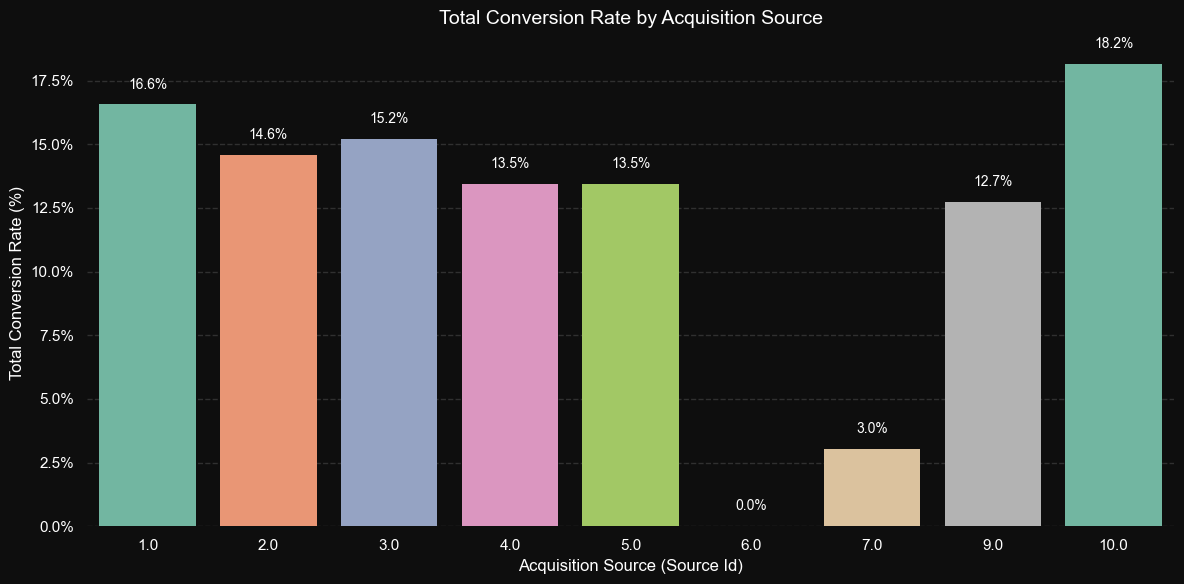

In [28]:
# ------------------------------------------------------------
# Total conversion rate by acquisition source (Visitors -> Buyers)
# ------------------------------------------------------------

# Unique visitors per source (from visits)
total_users_per_source = visits.groupby("Source Id")["Uid"].nunique()

# Unique buyers per source (from orders, based on first visit source)
converted_users_per_source = orders.groupby("first_source")["Uid"].nunique()

# Align indexes to avoid NaNs for missing sources
conversion_rate_per_source = (
    (converted_users_per_source / total_users_per_source)
    .fillna(0)
    .sort_values(ascending=False)
    .reset_index()
)

conversion_rate_per_source.columns = ["Source Id", "Total Conversion Rate"]

display(conversion_rate_per_source)

# Plot
palette = sns.color_palette("Set2", n_colors=len(conversion_rate_per_source))

plt.figure(figsize=(12, 6))
ax = plt.gca()

plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=conversion_rate_per_source,
    x="Source Id",
    y="Total Conversion Rate",
    palette=palette,
    ax=ax
)

ax.set_title("Total Conversion Rate by Acquisition Source", fontsize=14, color="white", pad=12)
ax.set_xlabel("Acquisition Source (Source Id)", fontsize=12, color="white")
ax.set_ylabel("Total Conversion Rate (%)", fontsize=12, color="white")

ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Value labels
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + 0.005,
        f"{h*100:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white"
    )

# Clean frame
for patch in ax.patches:
    patch.set_edgecolor("none")
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

### Conclusions — EDA — Revenue & Customer Value Analysis

The analysis of the time elapsed between a user’s first visit and their first purchase reveals a **highly front-loaded conversion pattern**.

A large proportion of users convert almost immediately: approximately **70% complete their first purchase on the same day as their first visit (Conversion 0d)**, and close to **90% convert within the first 10 days**. Beyond this initial window, conversion activity drops sharply and becomes **marginal after 30 days**, indicating that users who do not convert shortly after their first interaction are significantly less likely to convert at all.

From a business and marketing perspective, this behavior highlights that **customer value is primarily created very early in the user lifecycle**. The first interaction with the platform—through acquisition channel, landing experience, onboarding flow, and value proposition—plays a decisive role in driving revenue. As a result, marketing strategies should prioritize **early-stage engagement and rapid activation**, as these are the moments with the highest impact on conversion and downstream value.

The breakdown by acquisition source further supports this conclusion. Some channels exhibit exceptionally high short-term conversion rates (including cases approaching 100%), which suggests that these sources attract users with **strong purchase intent**. However, such results must be interpreted with caution, as they may be influenced by **small sample sizes** or highly targeted campaigns. Even so, they provide valuable signals for identifying channels worth deeper investigation and potential scaling.

Overall, the findings from this stage indicate that:
- Revenue generation is strongly driven by **early conversions**.
- Retargeting and remarketing efforts should be **time-bounded**, focusing on the first days or weeks after acquisition.
- Long-term conversion efforts for users who do not convert early are likely to yield **diminishing returns**.

These insights establish a solid foundation for the subsequent analysis of **lifetime value (LTV), customer acquisition costs (CAC), and marketing efficiency**, enabling more informed, data-driven business recommendations like refining the initial user journey to maximize conversion impact.

## EDA — Purchase Behavior & Order Dynamics

In this stage, the analysis focuses on understanding **how users generate revenue through their purchasing behavior**, beyond the timing of their first conversion.

The objective is to examine:
- How purchase activity is distributed across users
- How order volume evolves over time (daily and monthly)
- Differences in purchasing behavior across acquisition sources
- The concentration of orders among users and channels

By analyzing order frequency and volume, this section provides insight into **customer purchasing intensity**, helps identify **high-value behaviors**, and reveals whether revenue is driven by a broad base of users or concentrated among a smaller segment.

These insights are essential for interpreting lifetime value (LTV), evaluating marketing channel performance, and supporting more informed decisions around customer acquisition and retention strategies.

count    36523.000000
mean         1.380363
std          3.454461
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max        239.000000
Name: order_count, dtype: float64

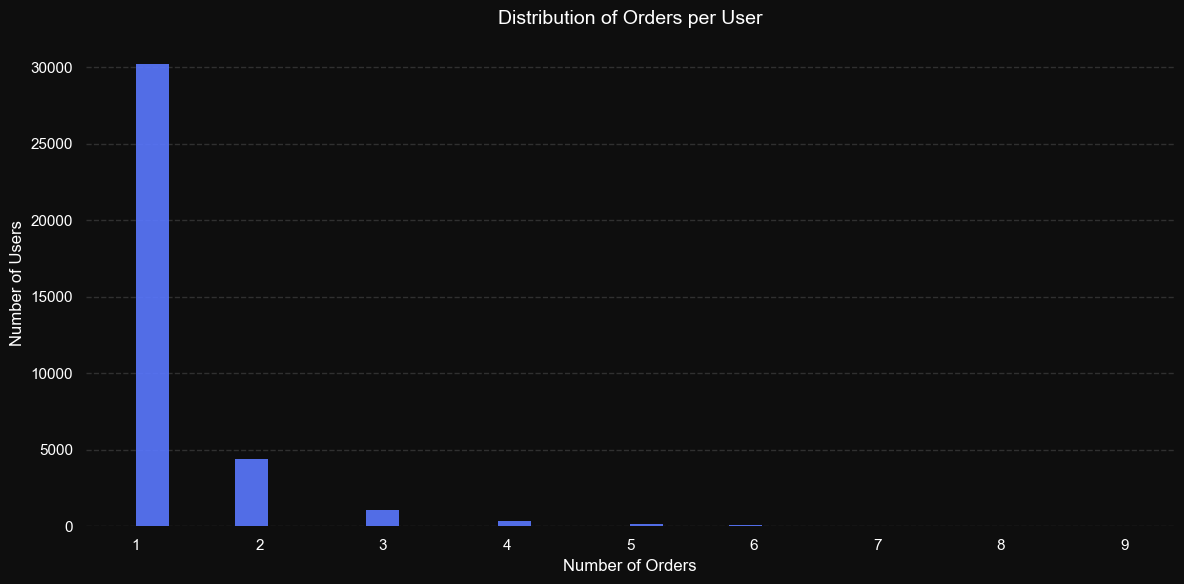

In [29]:
# ------------------------------------------------------------
# Distribution of orders per user
# ------------------------------------------------------------

# Orders per user
orders_per_user = (
    orders.groupby("Uid")["Buy Ts"]
    .count()
    .reset_index(name="order_count")
)

display(orders_per_user["order_count"].describe())

# Focus on users with fewer than 10 orders (long tail trimming for visualization)
orders_per_user_viz = orders_per_user.query("order_count < 10")

# Plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.histplot(
    data=orders_per_user_viz,
    x="order_count",
    bins=30,
    color="#5A78FF",
    edgecolor="none",
    alpha=0.9,
    ax=ax
)

# Titles & labels
ax.set_title(
    "Distribution of Orders per User",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Number of Orders", fontsize=12, color="white")
ax.set_ylabel("Number of Users", fontsize=12, color="white")

# Axis formatting
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.set_xticks(range(1, 10))
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

,order_date,orders
0,2017-06-01,96
1,2017-06-02,111
2,2017-06-03,67
3,2017-06-04,66
4,2017-06-05,161


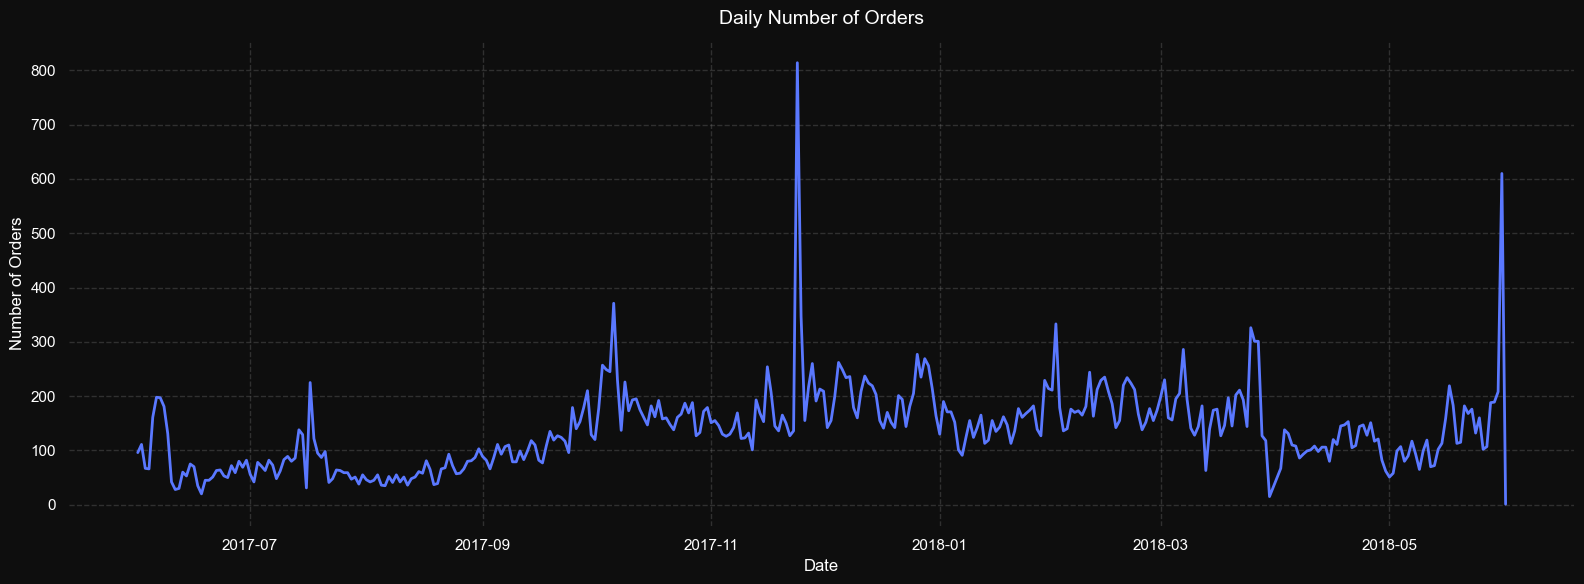

In [30]:
# ------------------------------------------------------------
# Orders per day
# ------------------------------------------------------------

# Create order date without timestamp
orders["order_date"] = orders["Buy Ts"].dt.date

# Orders per day
daily_orders = (
    orders.groupby("order_date")["Uid"]
    .count()
    .reset_index(name="orders")
)

display(daily_orders.head())

# Plot
plt.figure(figsize=(16, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.lineplot(
    data=daily_orders,
    x="order_date",
    y="orders",
    color="#5A78FF",
    linewidth=2,
    ax=ax
)

# Titles & labels
ax.set_title(
    "Daily Number of Orders",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Date", fontsize=12, color="white")
ax.set_ylabel("Number of Orders", fontsize=12, color="white")

# Axis formatting
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.grid(True, linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

,order_month,orders
0,2017-06,2354
1,2017-07,2363
2,2017-08,1807
3,2017-09,3387
4,2017-10,5679
5,2017-11,5659
6,2017-12,6218
7,2018-01,4721
8,2018-02,5281
9,2018-03,5326


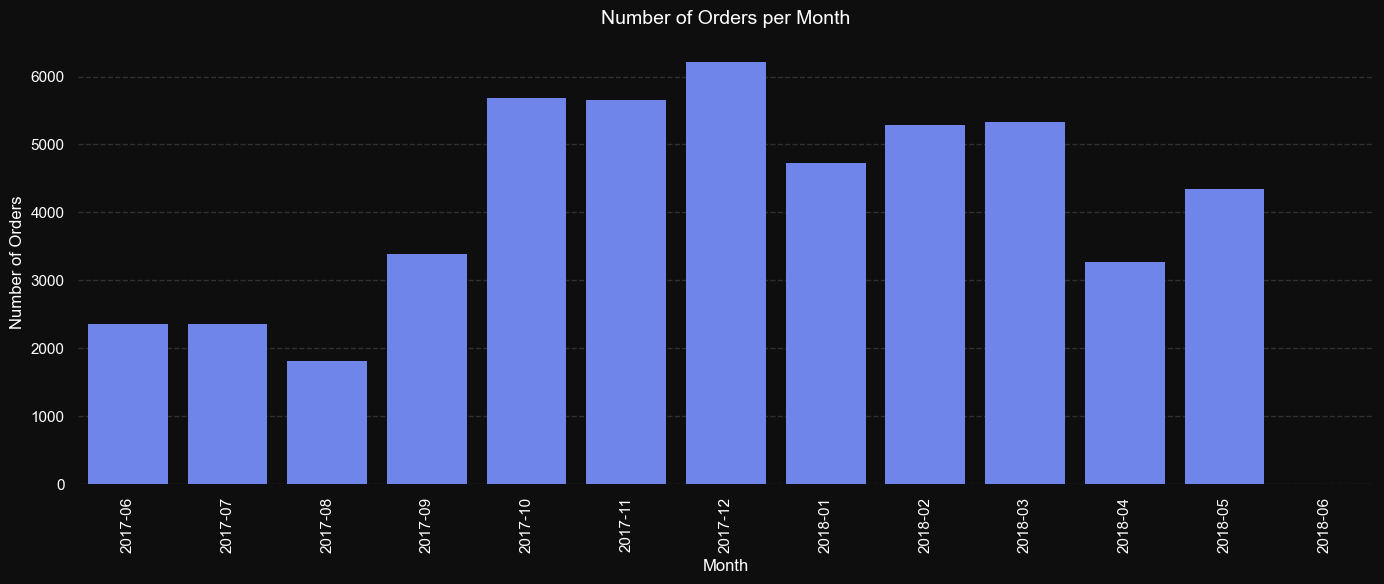

In [31]:
# ------------------------------------------------------------
# Orders per month
# ------------------------------------------------------------

# Create order month
orders["order_month"] = orders["Buy Ts"].dt.to_period("M").astype(str)

# Orders per month
monthly_orders = (
    orders.groupby("order_month")["Uid"]
    .count()
    .reset_index(name="orders")
)

display(monthly_orders)

# Plot
plt.figure(figsize=(14, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=monthly_orders,
    x="order_month",
    y="orders",
    color="#5A78FF",
    ax=ax
)

# Titles & labels
ax.set_title(
    "Number of Orders per Month",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Month", fontsize=12, color="white")
ax.set_ylabel("Number of Orders", fontsize=12, color="white")

# Axis formatting
ax.tick_params(axis="x", rotation=90, colors="white")
ax.tick_params(axis="y", colors="white")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove edgecolor from bars
for patch in ax.patches:
    patch.set_edgecolor("none")

plt.tight_layout()
plt.show()

,Source Id,Total Orders
0,3.0,12978
1,4.0,12676
2,5.0,9512
3,2.0,6415
4,1.0,5120
5,9.0,1643
6,10.0,1562
7,7.0,1


/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/2509758275.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


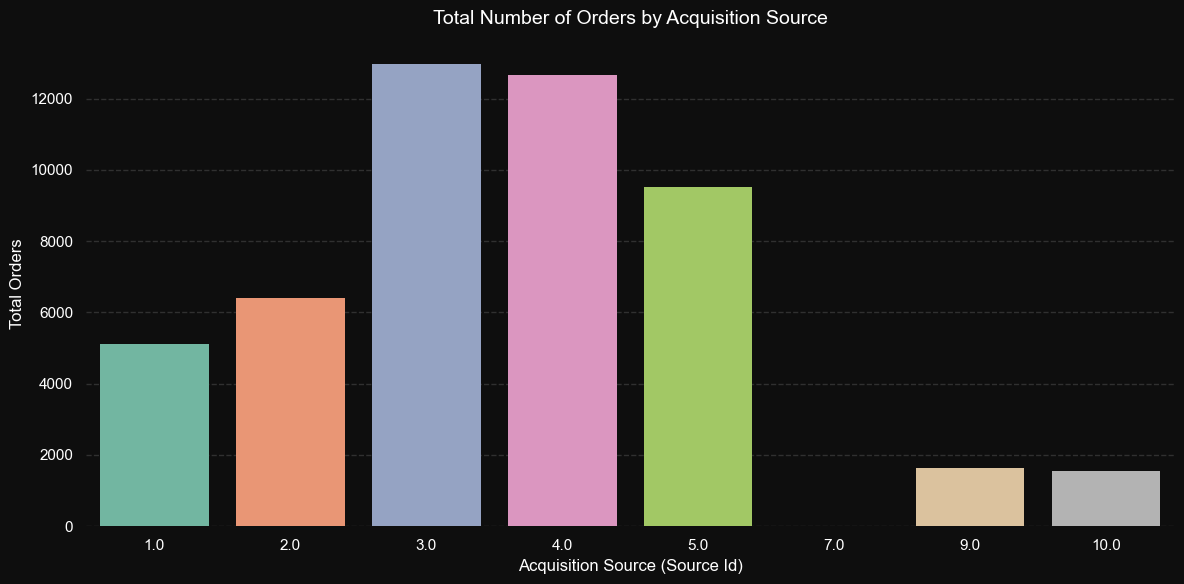

In [32]:
# ------------------------------------------------------------
# Total number of orders by acquisition source
# ------------------------------------------------------------

# Orders per source
orders_per_source = (
    orders.groupby("first_source")["Uid"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

orders_per_source.columns = ["Source Id", "Total Orders"]
display(orders_per_source)

# Plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=orders_per_source,
    x="Source Id",
    y="Total Orders",
    palette="Set2",
    ax=ax
)

# Titles & labels
ax.set_title(
    "Total Number of Orders by Acquisition Source",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Acquisition Source (Source Id)", fontsize=12, color="white")
ax.set_ylabel("Total Orders", fontsize=12, color="white")

# Axis formatting
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove edgecolor from bars
for patch in ax.patches:
    patch.set_edgecolor("none")

plt.tight_layout()
plt.show()

,Source Id,Avg Orders per User
0,2.0,1.823998
1,1.0,1.722746
2,9.0,1.517082
3,5.0,1.389222
4,3.0,1.269242
5,4.0,1.255298
6,10.0,1.194190
7,7.0,1.000000


/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/2429063704.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


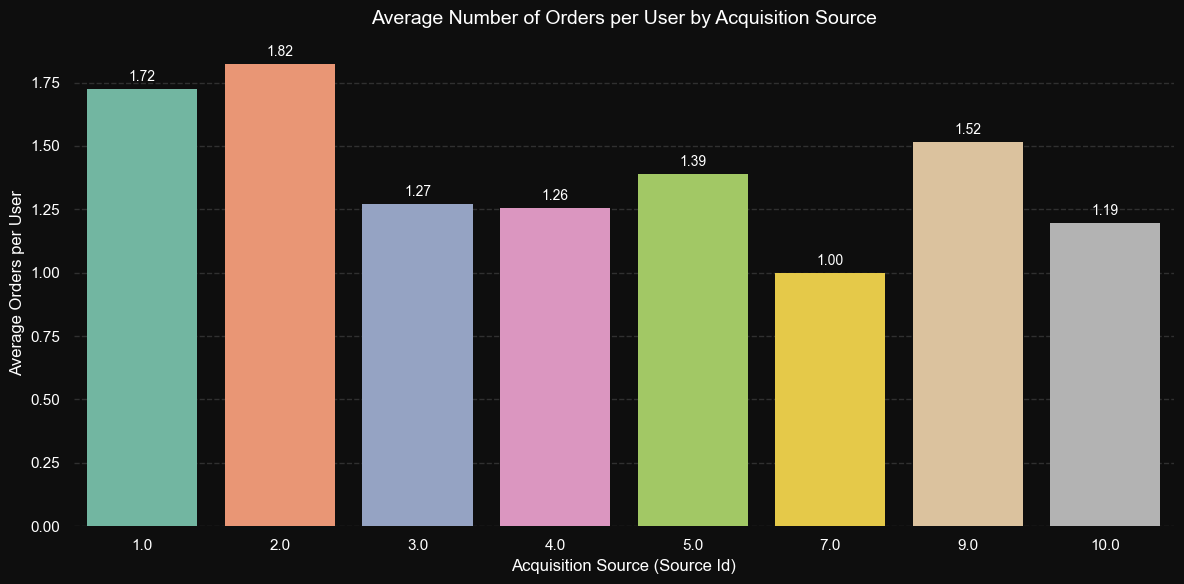

In [33]:
# ------------------------------------------------------------
# Average number of orders per user by acquisition source
# ------------------------------------------------------------

# Orders per user per source
orders_per_user = (
    orders.groupby(["first_source", "Uid"])["Buy Ts"]
    .count()
    .reset_index()
)

avg_orders_per_source = (
    orders_per_user.groupby("first_source")["Buy Ts"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

avg_orders_per_source.columns = ["Source Id", "Avg Orders per User"]
display(avg_orders_per_source)

# Plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=avg_orders_per_source,
    x="Source Id",
    y="Avg Orders per User",
    palette="Set2",
    ax=ax
)

# Titles & labels
ax.set_title(
    "Average Number of Orders per User by Acquisition Source",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Acquisition Source (Source Id)", fontsize=12, color="white")
ax.set_ylabel("Average Orders per User", fontsize=12, color="white")

# Axis formatting
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Value labels
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + 0.02,
        f"{h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white"
    )

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove edgecolor from bars
for patch in ax.patches:
    patch.set_edgecolor("none")

plt.tight_layout()
plt.show()

Average Order Value (AOV): $5.00



,Source Id,Average Order Value
0,2.0,7.39
1,1.0,5.93
2,5.0,5.61
3,4.0,4.38
4,3.0,4.08
5,9.0,3.47
6,10.0,2.98
7,7.0,1.22


/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/2432240563.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


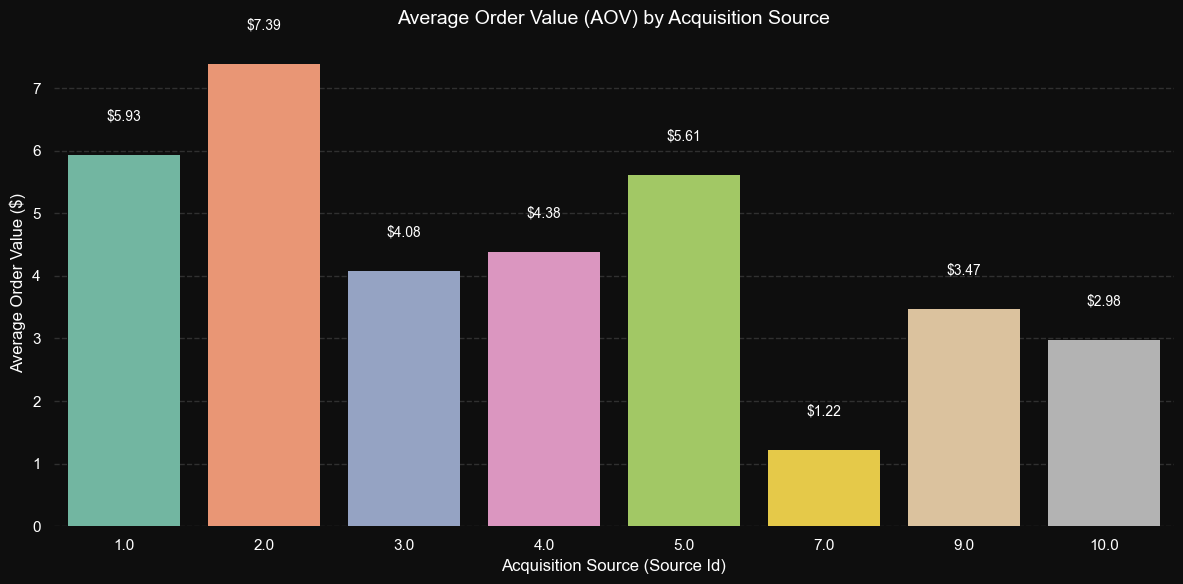

In [34]:
# ------------------------------------------------------------
# Average Order Value (AOV) overall and by acquisition source
# Styled bar chart (dark background)
# ------------------------------------------------------------

# Overall AOV
avg_order_value = orders["Revenue"].mean()
print(f"Average Order Value (AOV): ${avg_order_value:.2f}\n")

# AOV by source
avg_order_value_df = (
    orders.groupby("first_source")["Revenue"]
    .mean()
    .sort_values(ascending=False)
    .round(2)
    .reset_index()
)

avg_order_value_df.columns = ["Source Id", "Average Order Value"]
display(avg_order_value_df)

# Plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=avg_order_value_df,
    x="Source Id",
    y="Average Order Value",
    palette="Set2",
    ax=ax
)

# Titles & labels
ax.set_title(
    "Average Order Value (AOV) by Acquisition Source",
    fontsize=14,
    color="white",
    pad=12
)
ax.set_xlabel("Acquisition Source (Source Id)", fontsize=12, color="white")
ax.set_ylabel("Average Order Value ($)", fontsize=12, color="white")

# Axis formatting
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.grid(axis="y", linestyle="--", alpha=0.3, color="gray")
ax.set_axisbelow(True)

# Value labels
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + 0.5,
        f"${h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white"
    )

# Remove spines
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove edgecolor from bars
for patch in ax.patches:
    patch.set_edgecolor("none")

plt.tight_layout()
plt.show()

### Conclusions — EDA — Purchase Behavior & Order Dynamics

The analysis of orders and revenue patterns reveals several consistent behavioral and performance trends across time and acquisition sources.

From a temporal perspective, the number of orders increased steadily from late summer through December 2017, reaching its peak during the end-of-year period. This growth phase is followed by a relatively stable demand level in early 2018, with a noticeable seasonal dip around April. Overall, the platform shows clear signs of seasonality, with higher purchasing activity concentrated toward the end of the calendar year.

Despite this growth in total volume, user-level purchasing behavior remains limited. The distribution of orders per user shows that **the majority of customers (approximately 80%) place only a single order**, while repeat purchases are comparatively rare. This indicates that while user acquisition is effective at generating first purchases, long-term engagement and repeat buying behavior are weak. As a result, there is a significant opportunity to improve customer lifetime value through retention-focused strategies such as post-purchase incentives, loyalty programs, or personalized follow-up campaigns.

Clear differences also emerge across acquisition sources. Sources **1 and 2** stand out as higher-quality channels, combining:
- Higher average number of orders per user, and
- Higher average order value (AOV).

These characteristics directly translate into stronger long-term revenue potential and higher LTV. In contrast, **Source 7**, while exhibiting extremely fast conversion and a high short-term conversion rate, generates very low revenue per user due to its low average order value and limited repeat behavior. This suggests that fast conversion alone is not sufficient to define channel quality and that Source 7 should be carefully reevaluated from a profitability perspective.

Taken together, these findings highlight two key optimization opportunities:
1. **Retention and repeat purchasing**, as most users currently churn after a single order.
2. **Marketing channel reallocation**, prioritizing sources that generate both higher purchase frequency and higher order values rather than focusing solely on conversion speed.

Strengthening early user engagement while encouraging repeat purchases could significantly improve overall revenue efficiency without increasing acquisition spend.

## Revenue Drivers & Lifetime Value Analysis (LTV)

In this section, the analysis shifts from behavioral patterns to **revenue drivers and long-term value generation**. The objective is to understand how different user segments contribute to revenue over time and which dimensions have the strongest impact on customer lifetime value (LTV).

The analysis focuses on three complementary perspectives:

- **Purchase behavior by device**, evaluating whether certain devices are associated with higher order values or purchase volumes.
- **Order distribution by device**, identifying differences in engagement and purchasing frequency across platforms.
- **Customer Lifetime Value (LTV)**, quantifying the total revenue generated by users over their lifecycle and enabling comparisons across acquisition sources and user segments.

Together, these metrics provide a more complete view of **monetization quality**, allowing the identification of high-value segments and supporting more informed marketing investment decisions.

,Device,avg_order_value
0,desktop,5.158012
1,touch,4.361350


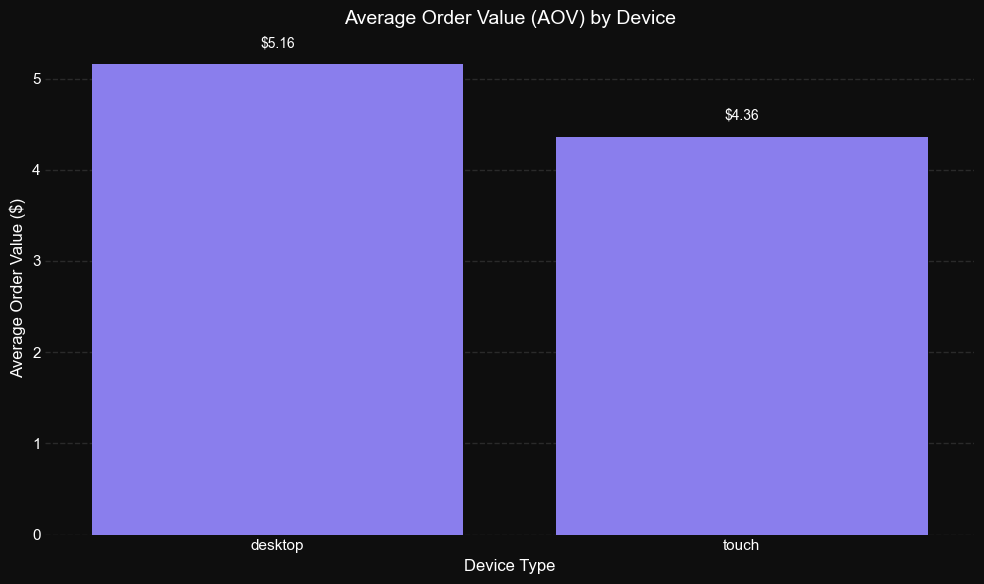

In [35]:
# ------------------------------------------------------------
# Average Order Value (AOV) by device — (robust)
# ------------------------------------------------------------

# 1) Ensure Device exists in orders (handle kernel resets + duplicate merges)
if "Device" not in orders.columns:
    # If Device was duplicated by a previous merge
    if "Device_x" in orders.columns:
        orders = orders.rename(columns={"Device_x": "Device"})
    elif "Device_y" in orders.columns:
        orders = orders.rename(columns={"Device_y": "Device"})
    else:
        # Merge device from visits (one device per user)
        uid_device = visits.groupby("Uid", as_index=False)["Device"].first()
        orders = orders.merge(uid_device, on="Uid", how="left")

# If both Device_x and Device_y exist, keep one and drop the other
if "Device_x" in orders.columns and "Device_y" in orders.columns:
    orders["Device"] = orders["Device_x"].fillna(orders["Device_y"])
    orders = orders.drop(columns=["Device_x", "Device_y"])

# 2) Make sure Revenue is numeric
orders["Revenue"] = pd.to_numeric(orders["Revenue"], errors="coerce")

# 3) Compute AOV by device
avg_order_device_df = (
    orders.dropna(subset=["Device", "Revenue"])
    .groupby("Device", as_index=False)["Revenue"]
    .mean()
    .sort_values("Revenue", ascending=False)
    .rename(columns={"Revenue": "avg_order_value"})
)

display(avg_order_device_df)

# 4) Plot (dark + purple + clean)
plt.figure(figsize=(10, 6))
ax = plt.gca()

plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=avg_order_device_df,
    x="Device",
    y="avg_order_value",
    color="#7b6cff",
    ax=ax
)

ax.set_title("Average Order Value (AOV) by Device", fontsize=14, color="white", pad=12)
ax.set_xlabel("Device Type", fontsize=12, color="white")
ax.set_ylabel("Average Order Value ($)", fontsize=12, color="white")

ax.tick_params(axis="x", colors="white", length=0)
ax.tick_params(axis="y", colors="white", length=0)

ax.grid(axis="y", linestyle="--", alpha=0.25, color="gray")
ax.set_axisbelow(True)

# Value labels
max_v = avg_order_device_df["avg_order_value"].max() if len(avg_order_device_df) else 0
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + (0.03 * max_v),
        f"${h:.2f}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="white"
    )

# Remove bar edges
for patch in ax.patches:
    patch.set_edgecolor("none")
    patch.set_linewidth(0)

# Remove rectangle border
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

,Device,Total Orders
0,desktop,40554
1,touch,9353


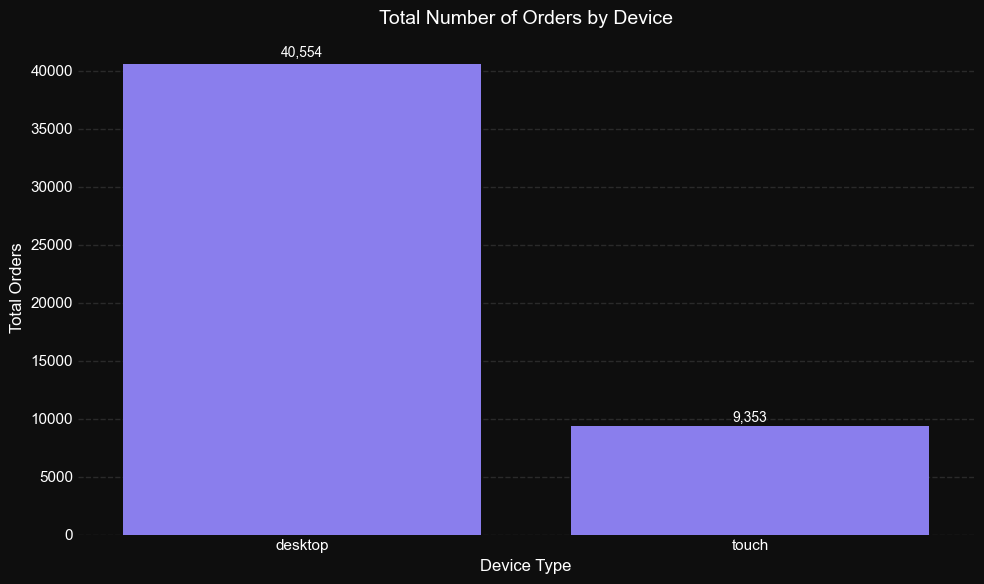

In [36]:
# ------------------------------------------------------------
# Total number of orders by device
# ------------------------------------------------------------

orders_by_device = (
    orders
    .groupby('Device')['Uid']
    .count()
    .sort_values(ascending=False)
    .reset_index()
)
orders_by_device.columns = ['Device', 'Total Orders']
display(orders_by_device)

plt.figure(figsize=(10, 6))
ax = plt.gca()

# Dark background
plt.gcf().patch.set_facecolor("#0e0e0e")
ax.set_facecolor("#0e0e0e")

sns.barplot(
    data=orders_by_device,
    x='Device',
    y='Total Orders',
    color="#7b6cff",
    ax=ax
)

# Titles & labels
ax.set_title("Total Number of Orders by Device", fontsize=14, color="white", pad=12)
ax.set_xlabel("Device Type", fontsize=12, color="white")
ax.set_ylabel("Total Orders", fontsize=12, color="white")

# Ticks + grid
ax.tick_params(axis='x', colors='white', length=0)   # remove tick marks
ax.tick_params(axis='y', colors='white', length=0)   # remove tick marks
ax.grid(axis='y', linestyle='--', alpha=0.25, color='gray')
ax.set_axisbelow(True)

# Remove bar edges
for patch in ax.patches:
    patch.set_edgecolor("none")
    patch.set_linewidth(0)

# Remove rectangle border (spines)
for spine in ax.spines.values():
    spine.set_visible(False)

# Value labels
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + (h * 0.01),
        f"{int(h):,}",
        ha='center',
        va='bottom',
        fontsize=10,
        color='white'
    )

plt.tight_layout()
plt.show()

In [37]:
# ------------------------------------------------------------
# Revenue metrics by acquisition source
# Total orders, AOV and total revenue
# ------------------------------------------------------------
orders_by_source = (
    orders
    .groupby("first_source", as_index=False)["Revenue"]
    .agg(
        Total_Orders="count",
        Avg_Order_Value="mean",
        Total_Revenue="sum"
    )
    .sort_values("Total_Revenue", ascending=False)
)

display(orders_by_source)

# ------------------------------------------------------------
# Revenue metrics by device and acquisition source
# ------------------------------------------------------------
orders_by_device_source = (
    orders
    .groupby(["Device", "first_source"], as_index=False)["Revenue"]
    .agg(
        Total_Orders="count",
        Avg_Order_Value="mean",
        Total_Revenue="sum"
    )
    .sort_values(["Device", "Total_Revenue"], ascending=[True, False])
)

display(orders_by_device_source)

,first_source,Total_Orders,Avg_Order_Value,Total_Revenue
3,4.0,12676,4.380379,55525.68
4,5.0,9512,5.608733,53350.27
2,3.0,12978,4.079736,52946.82
1,2.0,6415,7.390189,47408.06
0,1.0,5120,5.934033,30382.25
6,9.0,1643,3.468320,5698.45
7,10.0,1562,2.981408,4656.96
5,7.0,1,1.220000,1.22


,Device,first_source,Total_Orders,Avg_Order_Value,Total_Revenue
4,desktop,5.0,7962,5.985005,47652.61
2,desktop,3.0,10786,4.106916,44297.20
3,desktop,4.0,9798,4.446634,43568.12
1,desktop,2.0,5249,7.693509,40383.23
0,desktop,1.0,4143,5.909776,24484.20
6,desktop,9.0,1372,3.543550,4861.75
7,desktop,10.0,1243,3.161440,3929.67
5,desktop,7.0,1,1.220000,1.22
11,touch,4.0,2878,4.154816,11957.56
10,touch,3.0,2192,3.945995,8649.62


In [38]:
# ------------------------------------------------------------
# LTV calculations (overall + by source + by device)
# Robust version: consistent denominators, avoids duplicate merges
# ------------------------------------------------------------

# Ensure first_source exists in orders (if not, rebuild from visits)
if "first_source" not in orders.columns:
    first_source = visits.groupby("Uid")["Source Id"].first().rename("first_sourceUnit_first_source")
    orders = orders.merge(first_source, on="Uid", how="left")
    orders = orders.rename(columns={"first_source": "first_source", "Source Id": "first_source"})

# Ensure Device exists in orders (use first device per user from visits)
if "Device" not in orders.columns:
    uid_device = visits.sort_values("Start Ts").drop_duplicates("Uid")[["Uid", "Device"]]
    orders = orders.merge(uid_device, on="Uid", how="left")

# --- Overall LTV (full data) ---
ltv_total = orders["Revenue"].sum() / orders["Uid"].nunique()

# --- Clean LTV (no outliers + Revenue > 0) ---
# Build a clean version aligned to the same schema
orders_clean_base = orders[["Uid", "Revenue"]].copy()

Q1 = orders_clean_base["Revenue"].quantile(0.25)
Q3 = orders_clean_base["Revenue"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

orders_clean_base = orders_clean_base[
    (orders_clean_base["Revenue"] > 0) &
    (orders_clean_base["Revenue"] <= upper_bound)
].copy()

ltv_total_clean = orders_clean_base["Revenue"].sum() / orders_clean_base["Uid"].nunique()

print(
    f"LTV total (all data): ${ltv_total:.2f}\n"
    f"LTV total (clean: no outliers, Revenue > 0): ${ltv_total_clean:.2f}"
)

# --- LTV by acquisition source ---
ltv_by_source = (
    orders.groupby("first_source")
    .agg(total_revenue=("Revenue", "sum"), users=("Uid", "nunique"))
    .assign(LTV=lambda df: df["total_revenue"] / df["users"])
    .reset_index()
    .sort_values("LTV", ascending=False)
)
display(ltv_by_source)

# --- LTV by device ---
ltv_by_device = (
    orders.groupby("Device")
    .agg(total_revenue=("Revenue", "sum"), users=("Uid", "nunique"))
    .assign(LTV=lambda df: df["total_revenue"] / df["users"])
    .reset_index()
    .sort_values("LTV", ascending=False)
)
display(ltv_by_device)

LTV total (all data): $6.90
LTV total (clean: no outliers, Revenue > 0): $4.06


,first_source,total_revenue,users,LTV
1,2.0,47408.06,3517,13.479687
0,1.0,30382.25,2972,10.222830
4,5.0,53350.27,6847,7.791773
3,4.0,55525.68,10098,5.498681
6,9.0,5698.45,1083,5.261727
2,3.0,52946.82,10225,5.178173
7,10.0,4656.96,1308,3.560367
5,7.0,1.22,1,1.220000


,Device,total_revenue,users,LTV
0,desktop,209178.00,28919,7.233238
1,touch,40791.71,7132,5.719533


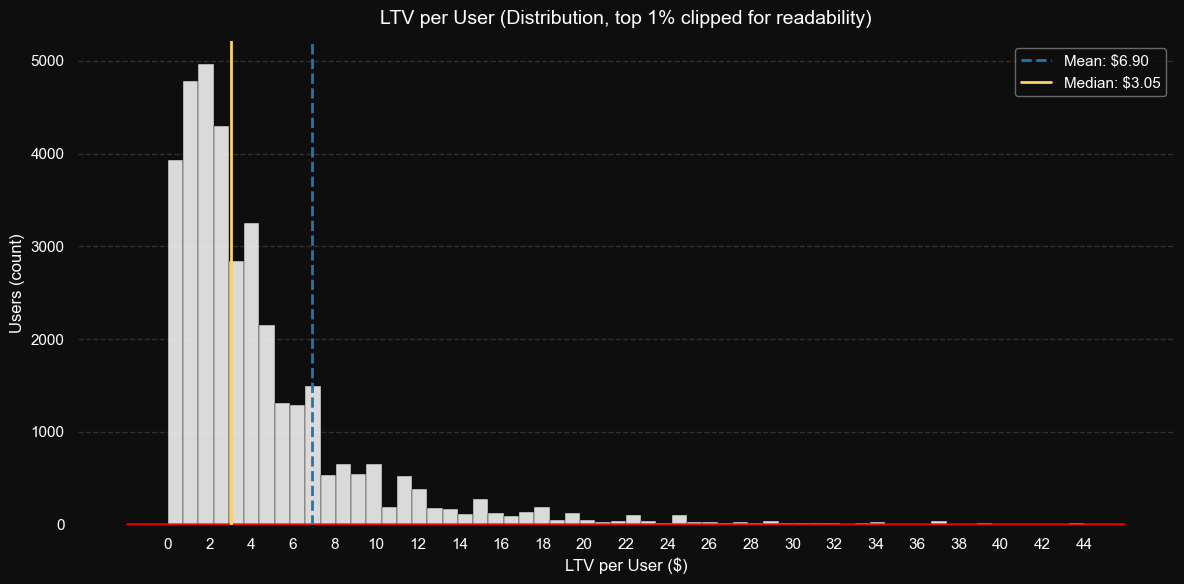

/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/4130558566.py:127: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


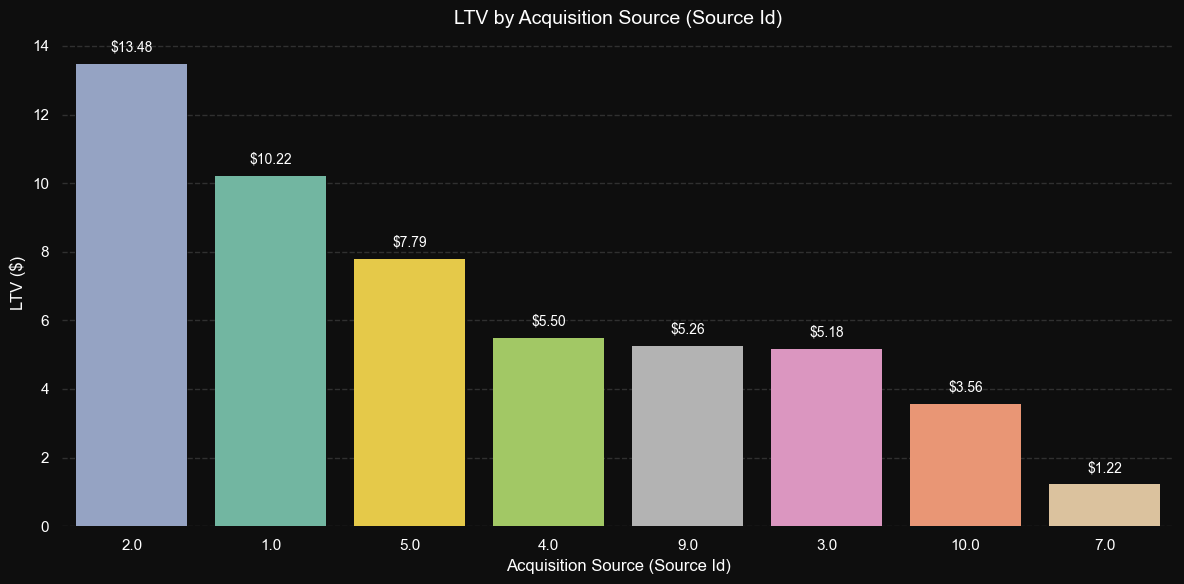

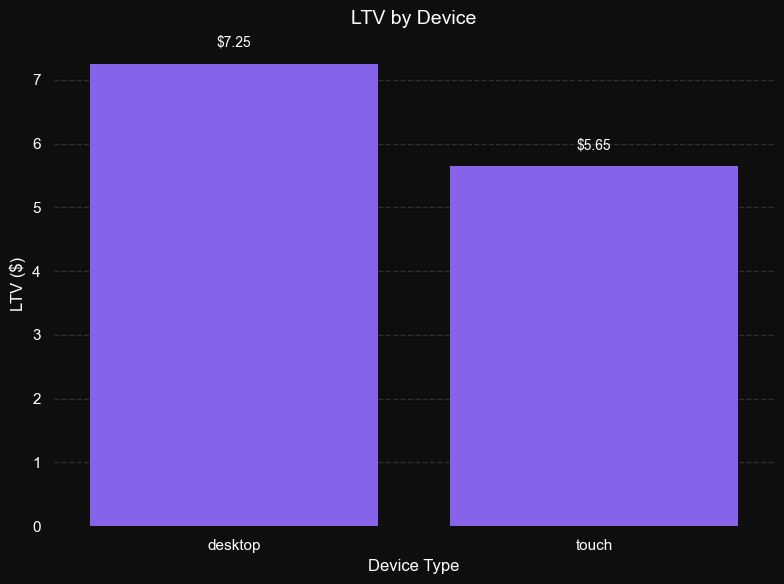

In [39]:
# ------------------------------------------------------------
# LTV Visuals 
# 1) LTV per user (distribution)
# 2) LTV by Source
# 3) LTV by Device
# ------------------------------------------------------------

PURPLE = "#7C4DFF"
BG = "#0e0e0e"
FG = "white"
GRID = "gray"

def style_dark(ax, title, xlabel, ylabel):
    plt.gcf().patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.set_title(title, fontsize=14, color=FG, pad=12)
    ax.set_xlabel(xlabel, fontsize=12, color=FG)
    ax.set_ylabel(ylabel, fontsize=12, color=FG)
    ax.tick_params(axis="x", colors=FG)
    ax.tick_params(axis="y", colors=FG)
    ax.grid(axis="y", linestyle="--", alpha=0.3, color=GRID)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)

def add_value_labels(ax, fmt="${:.2f}", dy_ratio=0.02):
    if not ax.patches:
        return
    ymax = max([p.get_height() for p in ax.patches]) or 1
    for p in ax.patches:
        h = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + dy_ratio * ymax,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=10,
            color=FG
        )
        p.set_edgecolor("none")

# ---- Build safe orders_enriched (no duplicates) ----
orders_base = orders[["Uid", "Buy Ts", "Revenue", "first_source"]].copy()
uid_device = visits.sort_values("Start Ts").drop_duplicates("Uid")[["Uid", "Device"]]
orders_enriched = orders_base.merge(uid_device, on="Uid", how="left")

# ---- LTV per user (distribution) ----
ltv_user = (
    orders_enriched.groupby("Uid", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "ltv_user"})
)

# limit view to reduce effect of extreme tail (visual only)
p99 = ltv_user["ltv_user"].quantile(0.99)
ltv_user_view = ltv_user[ltv_user["ltv_user"] <= p99].copy()

plt.figure(figsize=(12, 6))
ax = plt.gca()
plt.gcf().patch.set_facecolor(BG)
ax.set_facecolor(BG)

# Histogram (white) + KDE overlay (red) using seaborn's kdeplot (robust across versions)
sns.histplot(
    data=ltv_user_view,
    x="ltv_user",
    bins=60,
    stat="count",
    color="white",
    edgecolor=BG,
    linewidth=0.3,
    alpha=0.85,
    ax=ax
)
sns.kdeplot(
    data=ltv_user_view,
    x="ltv_user",
    color="red",
    linewidth=2,
    ax=ax
)

mean_v = ltv_user["ltv_user"].mean()
median_v = ltv_user["ltv_user"].median()

ax.axvline(mean_v, color="#1f77b4", linestyle="--", linewidth=2, label=f"Mean: ${mean_v:.2f}")
ax.axvline(median_v, color="#FFD166", linestyle="-", linewidth=2, label=f"Median: ${median_v:.2f}")

ax.set_title("LTV per User (Distribution, top 1% clipped for readability)", fontsize=14, color=FG, pad=12)
ax.set_xlabel("LTV per User ($)", fontsize=12, color=FG)
ax.set_ylabel("Users (count)", fontsize=12, color=FG)
ax.tick_params(axis="x", colors=FG)
ax.tick_params(axis="y", colors=FG)
ax.grid(axis="y", linestyle="--", alpha=0.3, color=GRID)
ax.set_axisbelow(True)
for spine in ax.spines.values():
    spine.set_visible(False)

leg = ax.legend(frameon=True)
leg.get_frame().set_facecolor(BG)
leg.get_frame().set_edgecolor(GRID)
for text in leg.get_texts():
    text.set_color(FG)

plt.xticks(range(0, int(p99) + 1, 2))
plt.tight_layout()
plt.show()

# ---- LTV by Source (fix palette key mismatch by forcing string keys) ----
ltv_by_source = (
    orders_enriched.groupby("first_source", as_index=False)
    .agg(total_revenue=("Revenue", "sum"), users=("Uid", "nunique"))
)
ltv_by_source["LTV"] = ltv_by_source["total_revenue"] / ltv_by_source["users"]

# normalize key type
ltv_by_source["first_source"] = ltv_by_source["first_source"].astype(str)
ltv_by_source = ltv_by_source.sort_values("LTV", ascending=False)

sources_sorted = sorted(ltv_by_source["first_source"].unique())
source_palette = sns.color_palette("Set2", n_colors=len(sources_sorted))
source_color_map = dict(zip(sources_sorted, source_palette))

plt.figure(figsize=(12, 6))
ax = plt.gca()
sns.barplot(
    data=ltv_by_source,
    x="first_source",
    y="LTV",
    palette=source_color_map,
    ax=ax
)
style_dark(ax, "LTV by Acquisition Source (Source Id)", "Acquisition Source (Source Id)", "LTV ($)")
add_value_labels(ax, fmt="${:.2f}", dy_ratio=0.02)
plt.tight_layout()
plt.show()

# ---- LTV by Device ----
ltv_by_device = (
    orders_enriched.groupby("Device", as_index=False)
    .agg(total_revenue=("Revenue", "sum"), users=("Uid", "nunique"))
)
ltv_by_device["LTV"] = ltv_by_device["total_revenue"] / ltv_by_device["users"]
ltv_by_device = ltv_by_device.sort_values("LTV", ascending=False)

plt.figure(figsize=(8, 6))
ax = plt.gca()
sns.barplot(
    data=ltv_by_device,
    x="Device",
    y="LTV",
    color=PURPLE,
    ax=ax
)
style_dark(ax, "LTV by Device", "Device Type", "LTV ($)")
add_value_labels(ax, fmt="${:.2f}", dy_ratio=0.03)
plt.tight_layout()
plt.show()

In [40]:
# ------------------------------------------------------------
# Top 10 Users by Lifetime Value (LTV)
# ------------------------------------------------------------

top_ltv_users = (
    orders_enriched
    .groupby("Uid", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "LTV"})
    .sort_values("LTV", ascending=False)
    .head(10)
)

print("Top 10 Users by Lifetime Value (LTV):")
display(top_ltv_users)

Top 10 Users by Lifetime Value (LTV):


,Uid,LTV
11014,5539673724080479777,11810.18
22073,11149926373378902217,10519.46
35670,17999372575896145244,1979.33
13459,6731421022966725351,1450.68
7206,3644482766749211722,1444.29
19248,9737640335185488211,1310.71
16979,8539015707073391293,1240.76
27482,13888745432979765063,1191.02
3276,1668300487562478408,1163.63
12541,6268225112727843212,1158.32


### Conclusions — Revenue Drivers & Lifetime Value Analysis (LTV)

The analysis of **Customer Lifetime Value (LTV)** reveals a highly skewed distribution, where the vast majority of users generate relatively low lifetime revenue. The median LTV per user is close to **$3**, while the average reaches **$6.90**, clearly reflecting the presence of a long tail of users with exceptionally high value. This indicates that a small fraction of customers contributes a disproportionate share of total revenue.

The **Top-10 users by LTV** ranking confirms this pattern: these users generate orders of magnitude more revenue than the average customer, with individual LTV values exceeding **$1,000**. From a business perspective, these users represent strategically critical segments and are strong candidates for retention initiatives, loyalty programs, and deeper behavioral analysis to better understand what drives long-term value.

When segmenting LTV by **acquisition source**, clear differences in traffic quality emerge. Certain sources not only convert quickly but also attract users with significantly higher lifetime value. In particular, **sources 1, 2, and 5** stand out for combining higher order values, stronger repeat behavior, and elevated LTV, making them the most profitable channels in the long run. In contrast, other sources show substantially lower LTVs, suggesting that their contribution is more short-term or volume-driven and should be carefully evaluated against their acquisition costs.

The **device-level analysis** further reinforces these findings. While **desktop** users account for the majority of total orders, they also exhibit a **higher LTV** compared to *touch* (mobile) users. This suggests that desktop traffic not only converts at scale but also produces more valuable customers over time. At the same time, the significant presence of mobile users highlights a clear opportunity: improving the mobile experience and conversion funnels could meaningfully increase overall LTV if mobile traffic can be converted more effectively into repeat and higher-value customers.

Overall, these results demonstrate that sustainable growth depends not only on acquiring more users, but on **acquiring and retaining the right users**. The most impactful levers for long-term revenue growth lie in prioritizing high-LTV acquisition sources, strengthening early retention strategies, and tailoring the user experience to maximize lifetime value across both channels and devices.

## Marketing Efficiency Analysis — CAC & ROMI

In this section, we evaluate the **effectiveness and profitability of marketing investments** across acquisition channels. While previous stages focused on user behavior, revenue generation, and lifetime value, this analysis closes the loop by linking **marketing spend to business outcomes**.

The objective is to understand not only how much was spent, but **how efficiently each channel converted marketing investment into valuable customers and revenue**. This allows us to identify which acquisition sources truly drive sustainable growth and which may require optimization or reallocation of budget.

Specifically, this stage addresses the following questions:

1. **How much money was spent on marketing?**  
   - Total marketing spend  
   - Spend by acquisition source  
   - Spend trends over time  

2. **What was the Customer Acquisition Cost (CAC) for each acquisition source?**  
   - Cost per acquired user  
   - Comparison of acquisition efficiency across channels  

3. **How profitable were the marketing investments? (ROMI)**  
   - Return on Marketing Investment by source  
   - Identification of high-performing vs. underperforming channels  

Together, these analyses provide a data-driven foundation for **budget allocation decisions**, ensuring that marketing resources are invested where they generate the highest long-term value.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2542 entries, 0 to 2541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   source_id  2542 non-null   int64         
 1   dt         2542 non-null   datetime64[ns]
 2   costs      2542 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 59.7 KB

Total marketing spend: $329,131.62



/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/2186345096.py:75: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


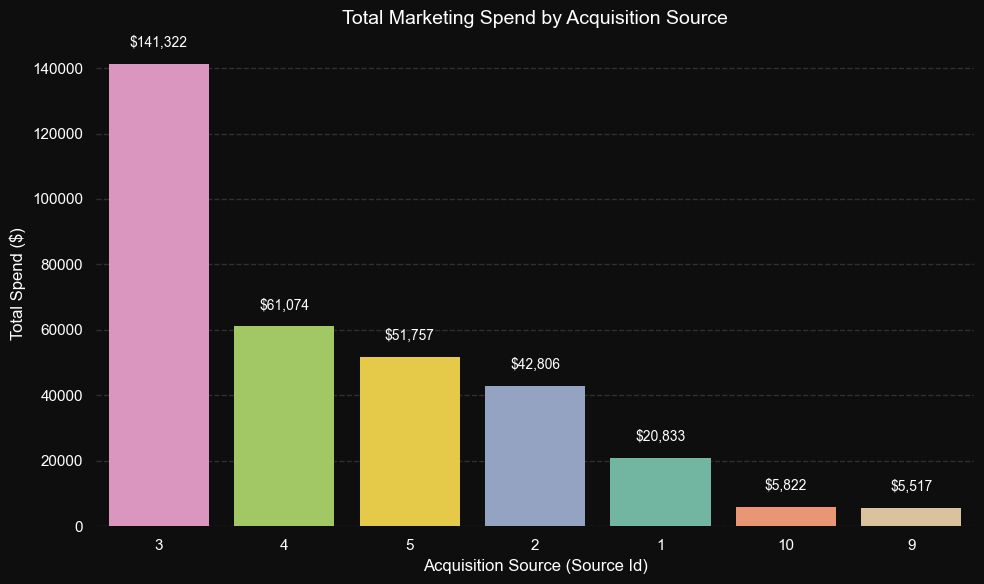

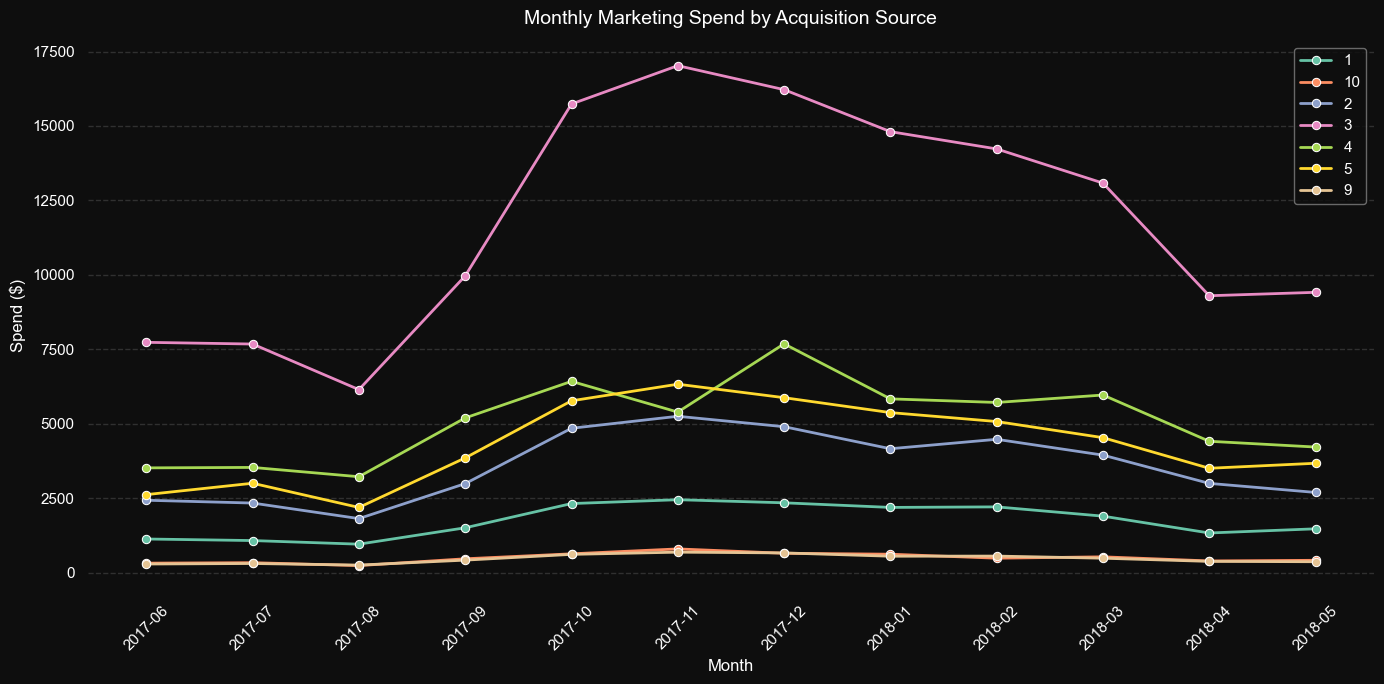

In [41]:
# ------------------------------------------------------------
# Marketing Spend Analysis
# Total, by acquisition source, and over time (dark style)
# ------------------------------------------------------------

BG = "#0e0e0e"
FG = "white"
GRID = "gray"

def style_dark(ax, title, xlabel, ylabel):
    plt.gcf().patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.set_title(title, fontsize=14, color=FG, pad=12)
    ax.set_xlabel(xlabel, fontsize=12, color=FG)
    ax.set_ylabel(ylabel, fontsize=12, color=FG)
    ax.tick_params(axis="x", colors=FG)
    ax.tick_params(axis="y", colors=FG)
    ax.grid(axis="y", linestyle="--", alpha=0.3, color=GRID)
    ax.set_axisbelow(True)
    for spine in ax.spines.values():
        spine.set_visible(False)

def add_value_labels(ax, fmt="${:,.0f}", dy_ratio=0.02):
    if not ax.patches:
        return
    ymax = max([p.get_height() for p in ax.patches]) or 1
    for p in ax.patches:
        h = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            h + dy_ratio * ymax,
            fmt.format(h),
            ha="center",
            va="bottom",
            fontsize=10,
            color=FG
        )
        p.set_edgecolor("none")

# ---- Inspect costs data ----
costs.info()
print()

# ---- Total marketing spend ----
total_cost = costs["costs"].sum()
print(f"Total marketing spend: ${total_cost:,.2f}\n")

# ---- Spend by acquisition source ----
costs_per_source = (
    costs.groupby("source_id", as_index=False)["costs"]
    .sum()
    .sort_values("costs", ascending=False)
)

# ------------------------------------------------------------
# SINGLE SOURCE OF TRUTH: color map for marketing sources
# (make it type-safe by using string keys everywhere)
# ------------------------------------------------------------
costs_per_source["source_id"] = costs_per_source["source_id"].astype(str)
costs["source_id"] = costs["source_id"].astype(str)

sources_all = sorted(costs["source_id"].unique())
source_palette = sns.color_palette("Set2", n_colors=len(sources_all))

MARKETING_SOURCE_COLOR_MAP = dict(zip(sources_all, source_palette))
# ------------------------------------------------------------

# IMPORTANT: bar colors must follow the plotted order (sorted by spend desc)
source_order_spend = costs_per_source["source_id"].tolist()
bar_palette = [MARKETING_SOURCE_COLOR_MAP[s] for s in source_order_spend]

plt.figure(figsize=(10, 6))
ax = plt.gca()

sns.barplot(
    data=costs_per_source,
    x="source_id",
    y="costs",
    order=source_order_spend,
    palette=bar_palette,
    ax=ax
)

style_dark(
    ax,
    "Total Marketing Spend by Acquisition Source",
    "Acquisition Source (Source Id)",
    "Total Spend ($)"
)
add_value_labels(ax, fmt="${:,.0f}", dy_ratio=0.03)

plt.tight_layout()
plt.show()

# ---- Monthly spend by source ----
costs["month"] = costs["dt"].dt.to_period("M").astype(str)

monthly_costs = (
    costs.groupby(["month", "source_id"], as_index=False)["costs"]
    .sum()
)

plt.figure(figsize=(14, 7))
ax = plt.gca()

sns.lineplot(
    data=monthly_costs,
    x="month",
    y="costs",
    hue="source_id",
    marker="o",
    linewidth=2,
    palette=MARKETING_SOURCE_COLOR_MAP,   # <-- SAME COLORS as bar chart
    ax=ax
)

style_dark(
    ax,
    "Monthly Marketing Spend by Acquisition Source",
    "Month",
    "Spend ($)"
)

ax.tick_params(axis="x", rotation=45)

leg = ax.legend(title=None)
for text in leg.get_texts():
    text.set_color(FG)
leg.get_frame().set_facecolor(BG)
leg.get_frame().set_edgecolor(GRID)

plt.tight_layout()
plt.show()

### Conclusions — Marketing Efficiency Analysis (Pre-CAC & ROMI)

The analysis of marketing spend reveals a **total cumulative investment of $329,131.62**, with a **highly concentrated allocation across acquisition sources**. Source **3** dominates the budget, accounting for **over 40% of total marketing spend**, followed by sources **4** and **5**. In contrast, sources **9** and **10** received only marginal investment, indicating either experimental usage or low strategic priority.

From a temporal perspective, **Source 3 shows a clear ramp-up in spending from mid-year onward**, peaking during the fourth quarter before slightly declining. This pattern suggests an aggressive acquisition strategy, potentially aligned with seasonal demand, promotional campaigns, or scaling efforts. Other sources display more stable or moderately increasing spend levels, indicating steadier acquisition tactics.

At this stage, spend concentration alone does not imply inefficiency or effectiveness. However, the strong imbalance in budget allocation highlights the **need for efficiency-focused evaluation**. In the next step, marketing spend will be directly contrasted with **customer acquisition outcomes and revenue generation**, enabling the calculation of **Customer Acquisition Cost (CAC)** and **Return on Marketing Investment (ROMI)** by source.

This transition from descriptive spend analysis to **performance-based efficiency metrics** is critical to determine whether high-investment channels are justified by proportional returns — or if budget reallocation opportunities exist.

orders rows: 50415 | costs rows: 2542
orders cols has first_source? True
orders cols has Uid? True

Merged CAC rows: 7


,source_id_raw,costs,source_id,users,CAC
0,3,141321.63,3,10225,13.821186
1,2,42806.04,2,3517,12.171180
2,5,51757.10,5,6847,7.559092
3,1,20833.27,1,2972,7.009849
4,4,61073.60,4,10098,6.048089
5,9,5517.49,9,1083,5.094635
6,10,5822.49,10,1308,4.451445


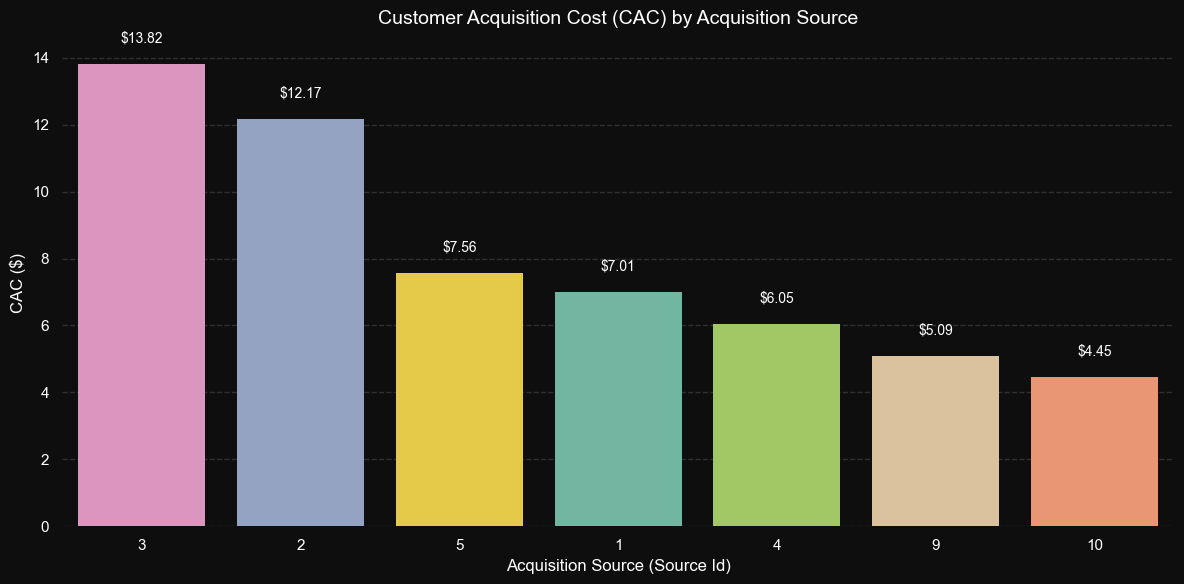

In [42]:
# ------------------------------------------------------------
# CAC by acquisition source — robust (fix empty merge + consistent colors)
# ------------------------------------------------------------

def normalize_source_id(s):
    """Turn 3, 3.0, '3.0', ' 3 ' -> '3' (string). Keeps NaN as NaN."""
    x = pd.to_numeric(s, errors="coerce")
    return x.dropna().astype(int).astype(str).reindex_like(s)

# --- Quick diagnostics (so we know why it's empty) ---
print("orders rows:", len(orders), "| costs rows:", len(costs))
print("orders cols has first_source?", "first_source" in orders.columns)
print("orders cols has Uid?", "Uid" in orders.columns)

# Rebuild costs_per_source safely (in case kernel reset)
costs_per_source = (
    costs.groupby("source_id", as_index=False)["costs"]
    .sum()
    .rename(columns={"source_id": "source_id_raw"})
)

# Normalize IDs (IMPORTANT)
orders["source_id_norm"] = normalize_source_id(orders["first_source"])
costs_per_source["source_id"] = normalize_source_id(costs_per_source["source_id_raw"])

# Users acquired per source (from orders)
users_per_source = (
    orders.dropna(subset=["source_id_norm"])
    .groupby("source_id_norm")["Uid"]
    .nunique()
    .reset_index()
    .rename(columns={"source_id_norm": "source_id", "Uid": "users"})
)

# CAC = spend / users
cac = (
    costs_per_source.dropna(subset=["source_id"])
    .merge(users_per_source, on="source_id", how="inner")
    .assign(CAC=lambda df: df["costs"] / df["users"])
    .sort_values("CAC", ascending=False)
    .reset_index(drop=True)
)

print("\nMerged CAC rows:", len(cac))
display(cac)

# If still empty, show why (outer merge diagnostic)
if cac.empty:
    diag = (
        costs_per_source.dropna(subset=["source_id"])
        .merge(users_per_source, on="source_id", how="outer", indicator=True)
        .sort_values(["_merge", "source_id"])
    )
    print("⚠️ CAC is empty. Here is an outer-merge diagnostic:")
    display(diag)
else:
    # --- Ensure palette keys match exactly the normalized IDs ---
    # If you already created MARKETING_SOURCE_COLOR_MAP earlier, we can reuse it,
    # but only if its keys match the normalized 'source_id' strings.
    if "MARKETING_SOURCE_COLOR_MAP" in globals():
        missing = set(cac["source_id"]) - set(MARKETING_SOURCE_COLOR_MAP.keys())
        if missing:
            print("Palette missing keys (will rebuild):", missing)
            sources_all = sorted(cac["source_id"].unique())
            source_palette = sns.color_palette("Set2", n_colors=len(sources_all))
            MARKETING_SOURCE_COLOR_MAP = dict(zip(sources_all, source_palette))
    else:
        sources_all = sorted(cac["source_id"].unique())
        source_palette = sns.color_palette("Set2", n_colors=len(sources_all))
        MARKETING_SOURCE_COLOR_MAP = dict(zip(sources_all, source_palette))

    # Plot (hue forces dict palette by key)
    plt.figure(figsize=(12, 6))
    ax = plt.gca()

    sns.barplot(
        data=cac,
        x="source_id",
        y="CAC",
        hue="source_id",
        dodge=False,
        palette=MARKETING_SOURCE_COLOR_MAP,
        ax=ax,
        legend=False
    )

    style_dark(
        ax,
        "Customer Acquisition Cost (CAC) by Acquisition Source",
        "Acquisition Source (Source Id)",
        "CAC ($)"
    )
    add_value_labels(ax, fmt="${:.2f}", dy_ratio=0.04)

    plt.tight_layout()
    plt.show()

Rows after merge: 7


,source_id,revenue,total_cost,ROMI
0,1,30382.25,20833.27,0.458352
2,2,47408.06,42806.04,0.107509
6,9,5698.45,5517.49,0.032798
5,5,53350.27,51757.10,0.030782
4,4,55525.68,61073.60,-0.090840
1,10,4656.96,5822.49,-0.200177
3,3,52946.82,141321.63,-0.625345


/var/folders/p1/6xjs3nrj1114kr5qgj0jm4cr0000gn/T/ipykernel_31794/1385176950.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


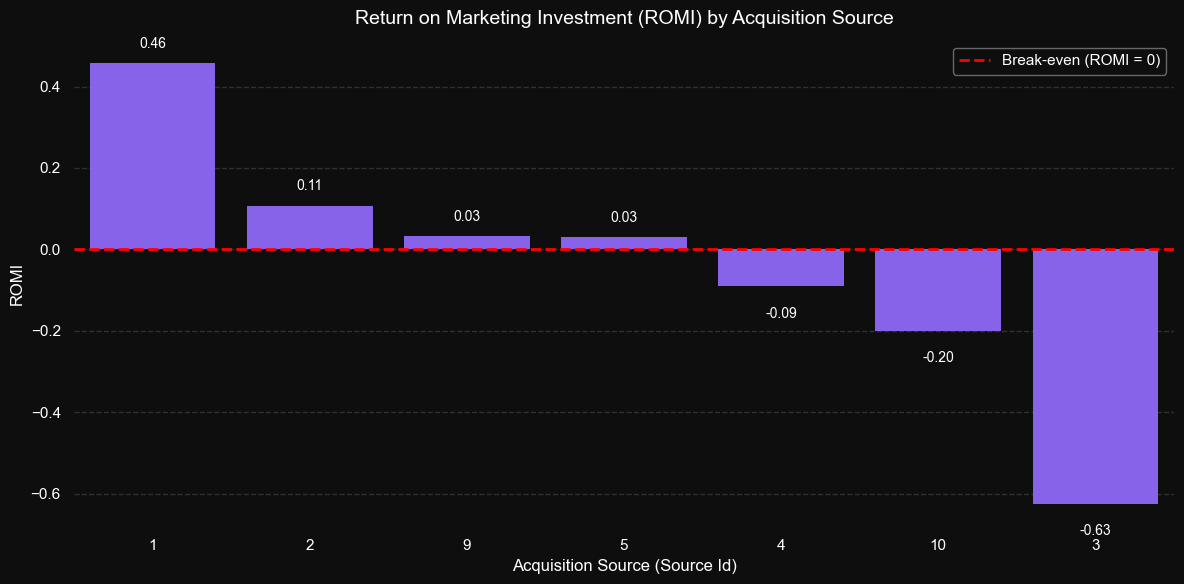

In [43]:
# ------------------------------------------------------------
# ROMI by acquisition source (ROBUST: fixes empty merge)
# ------------------------------------------------------------

# 1) Normalize source ids to the SAME format in both tables
#    (turn 1.0 -> "1", keep as string key)
orders_src = orders.copy()
costs_src = costs.copy()

orders_src["source_id"] = (
    pd.to_numeric(orders_src["first_source"], errors="coerce")
    .astype("Int64")
    .astype(str)
)

costs_src["source_id"] = (
    pd.to_numeric(costs_src["source_id"], errors="coerce")
    .astype("Int64")
    .astype(str)
)

# 2) Revenue & cost by source
revenue_by_source = (
    orders_src.groupby("source_id", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "revenue"})
)

costs_by_source = (
    costs_src.groupby("source_id", as_index=False)["costs"]
    .sum()
    .rename(columns={"costs": "total_cost"})
)

# 3) Merge (should NOT be empty now)
romi = revenue_by_source.merge(costs_by_source, on="source_id", how="inner")
print("Rows after merge:", len(romi))

# If still empty, show which keys don't match
if romi.empty:
    o_keys = set(revenue_by_source["source_id"])
    c_keys = set(costs_by_source["source_id"])
    print("In revenue but not in costs:", sorted(o_keys - c_keys))
    print("In costs but not in revenue:", sorted(c_keys - o_keys))
    raise ValueError("ROMI merge produced 0 rows. Source IDs do not match between orders and costs.")

# 4) ROMI
romi["ROMI"] = (romi["revenue"] - romi["total_cost"]) / romi["total_cost"]
romi_sorted = romi.sort_values("ROMI", ascending=False)
display(romi_sorted)

# 5) Colors (use your existing source_color_map if available; otherwise build one)
if "source_color_map" not in globals():
    sources_all = sorted(costs_by_source["source_id"].unique())
    source_palette = sns.color_palette("Set2", n_colors=len(sources_all))
    source_color_map = dict(zip(sources_all, source_palette))

source_order = romi_sorted["source_id"].tolist()
bar_palette = [source_color_map.get(s, "#7C4DFF") for s in source_order]

# 6) Plot
plt.figure(figsize=(12, 6))
ax = plt.gca()

sns.barplot(
    data=romi_sorted,
    x="source_id",
    y="ROMI",
    order=source_order,
    palette=bar_palette,
    ax=ax
)

# Break-even line
ax.axhline(0, color="red", linestyle="--", linewidth=2, label="Break-even (ROMI = 0)")

style_dark(
    ax,
    "Return on Marketing Investment (ROMI) by Acquisition Source",
    "Acquisition Source (Source Id)",
    "ROMI"
)

# Labels
for p in ax.patches:
    h = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        h + (0.03 if h >= 0 else -0.05),
        f"{h:.2f}",
        ha="center",
        va="bottom" if h >= 0 else "top",
        fontsize=10,
        color=FG
    )
    p.set_edgecolor("none")

leg = ax.legend()
leg.get_frame().set_facecolor(BG)
leg.get_frame().set_edgecolor(GRID)
for t in leg.get_texts():
    t.set_color(FG)

plt.tight_layout()
plt.show()

In [44]:
# ------------------------------------------------------------
# Executive table: CAC + LTV + ROMI by acquisition source (ROBUST VERSION)
# ------------------------------------------------------------

orders_exec = orders.copy()
costs_exec = costs.copy()

# --- Normalize source ids (type-safe) ---
orders_exec["source_id"] = (
    pd.to_numeric(orders_exec["first_source"], errors="coerce")  # handles '1.0'
)

# Drop rows where source_id can't be parsed (optional but clean)
orders_exec = orders_exec[orders_exec["source_id"].notna()].copy()
orders_exec["source_id"] = orders_exec["source_id"].astype(int)

costs_exec["source_id"] = pd.to_numeric(costs_exec["source_id"], errors="coerce")
costs_exec = costs_exec[costs_exec["source_id"].notna()].copy()
costs_exec["source_id"] = costs_exec["source_id"].astype(int)

# --- Revenue per source ---
revenue_by_source = (
    orders_exec.groupby("source_id", as_index=False)["Revenue"]
    .sum()
    .rename(columns={"Revenue": "revenue"})
)

# --- Users per source ---
users_by_source = (
    orders_exec.groupby("source_id", as_index=False)["Uid"]
    .nunique()
    .rename(columns={"Uid": "users"})
)

# --- Costs per source ---
costs_by_source = (
    costs_exec.groupby("source_id", as_index=False)["costs"]
    .sum()
    .rename(columns={"costs": "cost"})
)

# --- Merge all metrics ---
executive_metrics = (
    revenue_by_source
    .merge(users_by_source, on="source_id", how="inner")
    .merge(costs_by_source, on="source_id", how="inner")
)

# --- Compute metrics ---
executive_metrics["CAC"] = executive_metrics["cost"] / executive_metrics["users"]
executive_metrics["LTV"] = executive_metrics["revenue"] / executive_metrics["users"]
executive_metrics["ROMI"] = (executive_metrics["revenue"] - executive_metrics["cost"]) / executive_metrics["cost"]

# --- Format for readability ---
executive_metrics = executive_metrics.sort_values("ROMI", ascending=False).copy()
executive_metrics[["CAC", "LTV"]] = executive_metrics[["CAC", "LTV"]].round(2)
executive_metrics["ROMI"] = executive_metrics["ROMI"].round(2)
executive_metrics[["cost", "revenue"]] = executive_metrics[["cost", "revenue"]].round(0)

display(executive_metrics)

,source_id,revenue,users,cost,CAC,LTV,ROMI
0,1,30382.0,2972,20833.0,7.01,10.22,0.46
1,2,47408.0,3517,42806.0,12.17,13.48,0.11
5,9,5698.0,1083,5517.0,5.09,5.26,0.03
4,5,53350.0,6847,51757.0,7.56,7.79,0.03
3,4,55526.0,10098,61074.0,6.05,5.50,-0.09
6,10,4657.0,1308,5822.0,4.45,3.56,-0.20
2,3,52947.0,10225,141322.0,13.82,5.18,-0.63


### Conclusions — Marketing Efficiency Analysis (CAC & ROMI)

The analysis of marketing efficiency across acquisition channels reveals **strong asymmetries in performance**, both in terms of cost efficiency (CAC) and profitability (ROMI).

From a profitability perspective, **acquisition sources 1 and 2 clearly outperform the rest of the channels**. These sources exhibit the highest ROMI values, meaning that they generate substantially more revenue than the cost required to acquire customers. In practical terms, these channels not only recover their marketing investment, but do so with a wide margin, making them the most scalable and strategically valuable sources in the current marketing mix.

In contrast, **sources such as 3 and 10 show very low or marginal ROMI values**, indicating that the revenue generated barely compensates for the marketing spend, or in some cases fails to do so. This suggests structural inefficiencies in these channels, which may stem from poor targeting, low-quality traffic, or misaligned messaging. Without significant optimization, continued investment in these sources risks eroding overall marketing profitability.

When CAC is considered alongside ROMI, the results become even more actionable. **High-ROMI channels tend to combine relatively efficient acquisition costs with strong post-conversion value (LTV)**, reinforcing their strategic importance. Meanwhile, channels with moderate ROMI (such as sources 5 and 9) represent potential optimization opportunities: small improvements in conversion rate, retention, or average order value could meaningfully improve their profitability.

Overall, these findings support a **reallocation strategy** focused on:
- Prioritizing investment in high-ROMI channels (sources 1 and 2),
- Carefully optimizing or experimenting with mid-tier channels,
- Reassessing or deprioritizing consistently underperforming sources.

This data-driven approach enables marketing spend to be aligned not just with acquisition volume, but with **long-term customer value and sustainable growth**.

## Final Recommendations — Marketing Investment Strategy

Based on the integrated analysis of **marketing spend, customer acquisition cost (CAC), lifetime value (LTV), and return on marketing investment (ROMI)** by acquisition source, we recommend that the marketing team **rebalance its budget toward a smaller set of high-performing channels**, while scaling down or reconsidering structurally inefficient ones.

### Recommended Acquisition Sources

**Sources 1 and 2** clearly stand out as the most attractive platforms for sustained investment. These channels combine:
- The **highest ROMI** across all sources,
- **Low CAC**, indicating efficient user acquisition,
- Strong downstream performance, including **higher average order value (AOV)** and **greater customer lifetime value (LTV)**.

This combination shows that these channels not only convert efficiently, but also attract **high-quality users who generate long-term value**, making them the strongest candidates for scalable growth.

**Source 5** represents a solid secondary option. While its profitability is lower than that of sources 1 and 2, it maintains:
- A reasonable CAC,
- Consistent revenue contribution,
- A balanced relationship between acquisition volume and purchase value.

With incremental optimization, this channel can continue to play a supportive role in the acquisition mix.

**Source 9** emerges as a **controlled growth opportunity**. Although its current scale is limited, it demonstrates:
- Competitive CAC,
- Fast conversion behavior,
- Above-average order value.

Targeted experimentation and moderate budget increases could allow this source to scale profitably.

### Sources to Reduce or Reconsider

**Source 3** should be significantly reduced or fundamentally restructured. Despite receiving the largest share of the marketing budget, it delivers:
- The **lowest ROMI**,
- High acquisition costs,
- Weak revenue efficiency relative to spend.

Additionally, **sources 4 and 10 do not justify further investment at their current performance levels**. Both channels show limited returns, elevated CAC relative to value generated, and no clear signs of scalability. Unless their performance improves through strategic changes, continued spending on these channels would dilute overall marketing efficiency.

### Strategic Summary

In summary, the recommended strategy is to:
- **Prioritize proven high-return channels** (sources 1 and 2),
- **Maintain and optimize solid mid-performing channels** (source 5),
- **Experiment selectively with promising but smaller channels** (source 9),
- **Reduce or pause inefficient channels** (sources 3, 4, and 10).

This approach ensures that marketing investment is guided not by volume alone, but by **profitability, customer lifetime value, and sustainable growth potential**.